# Data Download
Put the SampleSubmission.csv, Test.csv, and Train.csv under the same directory
I put it in /Data - Lucky


In [2]:
#Import some libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sb
sb.set_style('darkgrid')
rcParams['figure.figsize'] = 8,8
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [3]:
#import data
train = pd.read_csv('/kaggle/input/datasets/hamzaghanmi/expresso-churn-prediction-challenge/Train.csv')
test=  pd.read_csv('/kaggle/input/datasets/hamzaghanmi/expresso-churn-prediction-challenge/Test.csv')
submission = pd.read_csv('/kaggle/input/datasets/hamzaghanmi/expresso-churn-prediction-challenge/SampleSubmission.csv')

In [4]:
train.columns, test.columns

(Index(['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
        'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
        'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK',
        'CHURN'],
       dtype='object'),
 Index(['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
        'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
        'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK'],
       dtype='object'))

# The Problem
(Taken from https://zindi.world/competitions/expresso-churn-prediction)


Expresso is an African telecommunications company that provides customers with airtime and mobile data bundles. The objective of this challenge is to develop a machine learning model to predict the likelihood of each Expresso customer “churning,” i.e. becoming inactive and not making any transactions for 90 days.

This solution will help Expresso to better serve their customers by understanding which customers are at risk of leaving.

Variable Definition Tables
| Variable | Description | Data type |
|---|---|---|
| REGION | Client location | object |
| TENURE | Duration in the network | object |
| MONTANT | Top-up amount | float64 |
| FREQUENCE_RECH | Number of times the customer refilled | float64 |
| REVENUE | Monthly revenue generated by the client | float64 |
| ARPU_SEGMENT | Revenue over 90 days / 3 | float64 |
| FREQUENCE | Number of times the client generated revenue | float64 |
| DATA_VOLUME | Number of connections | float64 |
| ON_NET | Calls within Expresso | float64 |
| ORANGE | Calls to Orange | float64 |
| TIGO | Calls to Tigo | float64 |
| ZONE1 | Calls to zone 1 | float64 |
| ZONE2 | Calls to zone 2 | float64 |
| MRG | Unclear definition; constant column | object |
| REGULARITY | Number of times the client is active over 90 days | int64 |
| TOP_PACK | Client’s most frequently activated pack | object |
| FREQ_TOP_PACK | Number of times the client activated the top pack | float64 |
| CHURN | Variable to predict (target) | int64 |

Details:
1. Income*: refer to how much revenue did the customer generate for the company
2. MRG^: Unclearly defined variable, after checking, it is just a constant column.

In [5]:
target = "CHURN"
X, y = train.copy(), train[target].copy()

# Drop constant columns
# dropping user_id as well for obvious reasons
# NOT Dropping target YET, just to simplify deduplication and other stuff down the line
X.drop(columns=['user_id', 'MRG'], inplace=True)

## Data Understanding

### Handling Missing Values

In [6]:
# Count missing values per column
missing_counts = X.isna().sum()
has_na_cols = missing_counts > 0

missing_counts[has_na_cols]

REGION             849299
MONTANT            756739
FREQUENCE_RECH     756739
REVENUE            726048
ARPU_SEGMENT       726048
FREQUENCE          726048
DATA_VOLUME       1060433
ON_NET             786675
ORANGE             895248
TIGO              1290016
ZONE1             1984327
ZONE2             2017224
TOP_PACK           902594
FREQ_TOP_PACK      902594
dtype: int64

In [7]:
cols_with_na = [
    'REGION',
    'MONTANT',
    'FREQUENCE_RECH',
    'REVENUE',
    'ARPU_SEGMENT',
    'FREQUENCE',
    'DATA_VOLUME',
    'ON_NET',
    'ORANGE',
    'TIGO',
    'ZONE1',
    'ZONE2',
    'TOP_PACK',
    'FREQ_TOP_PACK'
]

# Helper function
def summarize_against_label(df, col, label):
    missing = df[col].isna()
    summary = (
        pd.DataFrame({
            f'{col}_is_missing': missing,
            'CHURN': label
        }).groupby(f"{col}_is_missing")['CHURN']
        .agg(customer="size", churn_rate="mean")
    )
    return summary

# Check one by one, kinda manual, but, eh, unescapable
# Purpose: Find whether "NaN" has a meaning or actually missing
for col in cols_with_na:
    summary = summarize_against_label(X, col, y)
    print(summary)
    print("=" * 50)

# Manually check: Essentially, EVERY NA columns has some association with churn rate
# Need to validate later, but, keeping every cols for now.
na_cols_with_importance = [
    'REGION',
    'MONTANT',
    'FREQUENCE_RECH',
    'REVENUE',
    'ARPU_SEGMENT',
    'FREQUENCE',
    'DATA_VOLUME',
    'ON_NET',
    'ORANGE',
    'TIGO',
    'ZONE1', # Very many missing values, has a 0.2 correlation rate with CHURN
    'ZONE2', # Same with ZONE1
    'TOP_PACK',
    'FREQ_TOP_PACK'
]

                   customer  churn_rate
REGION_is_missing                      
False               1304749    0.018020
True                 849299    0.447987
                    customer  churn_rate
MONTANT_is_missing                      
False                1397309    0.050035
True                  756739    0.441463
                           customer  churn_rate
FREQUENCE_RECH_is_missing                      
False                       1397309    0.050035
True                         756739    0.441463
                    customer  churn_rate
REVENUE_is_missing                      
False                1428000    0.054057
True                  726048    0.450098
                         customer  churn_rate
ARPU_SEGMENT_is_missing                      
False                     1428000    0.054057
True                       726048    0.450098
                      customer  churn_rate
FREQUENCE_is_missing                      
False                  1428000    0.054057
True   

In [8]:
# is 0 used for numeric columns?
num_cols = X.select_dtypes(include=np.number).columns
for col in num_cols:
    print(f"Column {col}: {X[col].describe()['min']}")

Column MONTANT: 10.0
Column FREQUENCE_RECH: 1.0
Column REVENUE: 1.0
Column ARPU_SEGMENT: 0.0
Column FREQUENCE: 1.0
Column DATA_VOLUME: 0.0
Column ON_NET: 0.0
Column ORANGE: 0.0
Column TIGO: 0.0
Column ZONE1: 0.0
Column ZONE2: 0.0
Column REGULARITY: 1.0
Column FREQ_TOP_PACK: 1.0
Column CHURN: 0.0


In [9]:
# Deal with Missing Values
# Since each columns has some level of association:
# Numeric column -> 0
# We can use 0 here because it does indicate the user has no activity in that area, which is the assumption
# Categorical column - None
# No need for ColumnTransformer, as these are constant replacement of NaNs

# I know this includes the target column, but, no Na values in the target column, so, no worries
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

num_cols, cat_cols
X[num_cols] = X[num_cols].fillna(0)
X[cat_cols] = X[cat_cols].fillna("None")

In [10]:
# No More NaN values!
missing_counts = X.isna().sum()
has_na_cols = missing_counts > 0

missing_counts[has_na_cols]

Series([], dtype: int64)

### Any Duplicates?


In [11]:
print(f"Duplicated rows count = {X.duplicated().sum()}")
# Note -> YES, A lot of duplications. But, this are different customers...
# How does each "duplication group" compare with the churn label?

# Exact duplicates include the label; feature duplicates exclude it.
total_duplicates = X.duplicated().sum()
feature_cols = X.columns.drop(target).tolist()
duplicate_mask = X.duplicated(subset=feature_cols, keep=False)
duplicate_rows = X.loc[duplicate_mask].copy()

# Count both labels for each repeated feature combination.
duplicate_summary = (
    duplicate_rows.groupby(feature_cols, dropna=False, observed=True, sort=False)[target]
    .agg(rows="size", distinct_labels="nunique", churn_1="sum")
)
duplicate_summary["churn_0"] = duplicate_summary["rows"] - duplicate_summary["churn_1"]
conflicting_groups = duplicate_summary.loc[
    duplicate_summary["distinct_labels"] > 1
].sort_values("rows", ascending=False)

print(f"Rows in repeated feature groups (including first occurrences): {len(duplicate_rows):,}")
print(f"Repeated feature groups: {len(duplicate_summary):,}")
print(f"Groups with consistent labels: {(duplicate_summary['distinct_labels'] == 1).sum():,}")
print(f"Groups with conflicting labels: {len(conflicting_groups):,}")
print(f"Rows in conflicting groups: {conflicting_groups['rows'].sum():,}")

# Each displayed group has identical features but both CHURN=0 and CHURN=1.
display(conflicting_groups.head(10).reset_index())


Duplicated rows count = 661897
Rows in repeated feature groups (including first occurrences): 692,284
Repeated feature groups: 21,753
Groups with consistent labels: 13,119
Groups with conflicting labels: 8,634
Rows in conflicting groups: 633,275


,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,TOP_PACK,FREQ_TOP_PACK,rows,distinct_labels,churn_1,churn_0
0,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,None,0.0,133708,2,105059,28649
1,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,None,0.0,72200,2,49960,22240
2,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,None,0.0,45608,2,28196,17412
3,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,None,0.0,31621,2,18087,13534
4,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,None,0.0,23153,2,12080,11073
5,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,None,0.0,17679,2,8544,9135
6,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,None,0.0,13980,2,6256,7724
7,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,None,0.0,10968,2,4691,6277
8,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,None,0.0,8761,2,3538,5223
9,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,None,0.0,7448,2,2827,4621


# Working Data

In [12]:
# These duplicates are irreducible noise
# What do we do with irreducible noise? Keep them all.
# CARE: Need to do hashing to ensure that isolation between train and valid sets.
train_y = X[target]
train_X = X.drop(columns=[target]).copy()
hashes = pd.util.hash_pandas_object(train_X, index=False)

test_X = test.copy()
num_cols_without_churn = test_X.select_dtypes(include=np.number).columns
test_X[num_cols_without_churn] = test_X[num_cols_without_churn].fillna(0)
test_X[cat_cols] = test_X[cat_cols].fillna("None")

len(train_X), len(hashes), len(hashes.unique())

(2154048, 2154048, 1483517)

# Exploratory Data Analysis
Let's just check around the data a bit

In [13]:
# Training data label distribution
X['CHURN'].value_counts(normalize=True)

# 18.7% has label 1. The rest has label 0.
# Despite the imbalance, there is ~400K rows with label 1
# Obviously, don't use accuracy as a metric.
# We'll probably report AUC "The evaluation metric for this challenge is Area Under the Curve (AUC)." from original submission.
# Or, we can try around with class weights. But, eh, let's see how the model performs first.
18.7/100*len(X)

402806.976

In [14]:
# Clearer view on the irreducible noise
g = y.groupby(hashes)

print(g.nunique().value_counts()) # For each hash, how many unique labels are thehre
print(g.var().mean()) # Get mean variance. Rows with 1 unique label has 0 variance.

# Explanation: Around 0.5% of the rows have conflicting labels.
# Since this is a binary classification problem, the mean variance here indicates that:
# p * (1-p) = 0.1289 --> irreducible noise among duplicate features.
print(f"Irreducible noise rows ratio: {8634 / (1474883 + 8634):.4f}")

CHURN
1    1474883
2       8634
Name: count, dtype: int64
0.12889918151635607
Irreducible noise rows ratio: 0.0058


In [15]:
corr = X[num_cols].corr(method="spearman")
corr.style.background_gradient(cmap='coolwarm')

,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK,CHURN
MONTANT,1.000000,0.967862,0.984710,0.985074,0.950003,0.469241,0.751966,0.840618,0.669293,0.209906,0.225801,0.804861,0.917547,-0.444721
FREQUENCE_RECH,0.967862,1.000000,0.955316,0.955662,0.972496,0.457633,0.746147,0.817527,0.645226,0.191712,0.211568,0.796937,0.932022,-0.447782
REVENUE,0.984710,0.955316,1.000000,0.999635,0.963829,0.473307,0.756160,0.846877,0.672493,0.211046,0.226224,0.810161,0.922096,-0.448988
ARPU_SEGMENT,0.985074,0.955662,0.999635,1.000000,0.963285,0.473429,0.756089,0.846903,0.672582,0.211087,0.226332,0.810012,0.922443,-0.448979
FREQUENCE,0.950003,0.972496,0.963829,0.963285,1.000000,0.465764,0.732153,0.811716,0.640149,0.194203,0.221126,0.802615,0.913607,-0.450403
DATA_VOLUME,0.469241,0.457633,0.473307,0.473429,0.465764,1.000000,0.229490,0.251695,0.233599,0.057516,0.106994,0.426799,0.456912,-0.228314
ON_NET,0.751966,0.746147,0.756160,0.756089,0.732153,0.229490,1.000000,0.766741,0.594901,0.166762,0.105664,0.705441,0.736953,-0.410278
ORANGE,0.840618,0.817527,0.846877,0.846903,0.811716,0.251695,0.766741,1.000000,0.693889,0.192717,0.152555,0.698710,0.795322,-0.404956
TIGO,0.669293,0.645226,0.672493,0.672582,0.640149,0.233599,0.594901,0.693889,1.000000,0.149892,0.107524,0.566113,0.630965,-0.298603
ZONE1,0.209906,0.191712,0.211046,0.211087,0.194203,0.057516,0.166762,0.192717,0.149892,1.000000,0.082976,0.170887,0.178580,-0.084601


In [16]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y) # Same as groupby([x, y]).size().unstack(), needed by chi2_contingency
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1))) # 0 = No drift, 1 = fully determined

print("Count of categories") # Checking, because chi2 is sensitive to number of categories (biased as number of categories increases)
for col in cat_cols:
    print(col, train_X[col].nunique())

print("\nCramer's V values for categorical features:")
for col in cat_cols:
    print(col, round(cramers_v(train_X[col], train_y), 3))

print("\nCramer's V values for categorical features (excluding 'None'):")
for check_col in cat_cols:
    mask = train_X[check_col] != "None"
    print(check_col, round(cramers_v(train_X.loc[mask, check_col], train_y[mask]), 3))

# So: The signals are coming from the "None" instead of the values themselves.

Count of categories
REGION 15
TENURE 8
TOP_PACK 141

Cramer's V values for categorical features:
REGION 0.538
TENURE 0.05
TOP_PACK 0.446

Cramer's V values for categorical features (excluding 'None'):
REGION 0.035
TENURE 0.05
TOP_PACK 0.098


## Comparing Feature Distribution

CHURN                     0                   1       
                       mean  median        mean median
MONTANT         4326.059606  1800.0  394.083815    0.0
FREQUENCE_RECH     9.029883     4.0    0.759650    0.0
REVENUE         4404.871181  1819.0  397.636275    0.0
ARPU_SEGMENT    1468.295098   606.0  132.546665    0.0
FREQUENCE         11.167054     6.0    1.034070    0.0
DATA_VOLUME     2020.208588     0.0  361.671239    0.0
ON_NET           214.569852     8.0   10.381768    0.0
ORANGE            67.699080     9.0    4.048370    0.0
TIGO              11.251595     0.0    0.683551    0.0
ZONE1              0.748803     0.0    0.188598    0.0
ZONE2              0.556992     0.0    0.145312    0.0
REGULARITY        33.182215    34.0    5.777349    2.0
FREQ_TOP_PACK      6.511096     2.0    0.517931    0.0


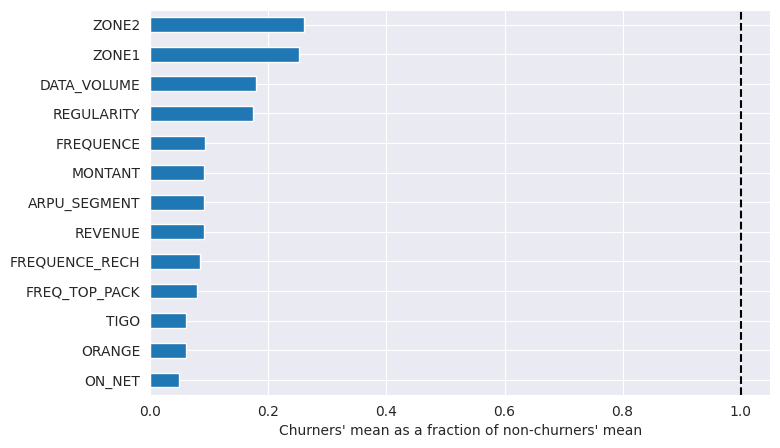

In [17]:
# Train with churn 0 vs churn 1
# Numeric features: Drift in mean and median
num_report = train_X[num_cols_without_churn].groupby(train_y).agg(["mean", "median"]).T.unstack()

import matplotlib.pyplot as plt

print(num_report)

means = num_report.xs("mean", axis=1, level=1)      # columns: 0 and 1

ratio = (means[1] / means[0]).sort_values()
ax = ratio.plot.barh(figsize=(8, 5))
ax.axvline(1, color="black", linestyle="--")
ax.set_xlabel("Churners' mean as a fraction of non-churners' mean")
plt.show()

# No obvious IDENTICAL distribution. Maybe Zone1 and Zone2? But, eh, for now... yeah.
# There's some obvious drifts that do indicate importance though.

In [18]:
# Categorical: share of each category within churn 0 and churn 1
for col in cat_cols:
    shares = pd.crosstab(train_X[col], train_y, normalize="columns")
    shares["gap"] = (shares[1] - shares[0]).abs()
    print(shares.sort_values("gap", ascending=False).head(10))

# For Region: If there's a None value, the user is very unlikely to be churned
# For Tenure: Not exactly different between churn vs non-churn. This is probably one of the safest thing to drop. 
#             Also make sense --> People can stop using your service at any time, really.
# For TOP_PACK: "None" seems to be the strongest signal, All-net 500F=2000F;5d comes 2nd (large gap, but most doesn't churn, just shows that it is a popular pack)


CHURN               0         1       gap
REGION                                   
None         0.267890  0.941802  0.673913
DAKAR        0.287646  0.024439  0.263207
THIES        0.101206  0.007265  0.093941
SAINT-LOUIS  0.067635  0.003763  0.063873
LOUGA        0.055697  0.003911  0.051786
KAOLACK      0.054120  0.005626  0.048493
DIOURBEL     0.037159  0.004654  0.032506
TAMBACOUNDA  0.030986  0.002094  0.028892
KAFFRINE     0.024940  0.000782  0.024158
KOLDA        0.021900  0.001032  0.020868
CHURN                 0         1       gap
TENURE                                     
K > 24 month   0.953573  0.926738  0.026836
I 18-21 month  0.018817  0.030563  0.011746
H 15-18 month  0.010904  0.017139  0.006236
G 12-15 month  0.005822  0.011666  0.005845
J 21-24 month  0.005592  0.007273  0.001680
F 9-12 month   0.004050  0.005545  0.001495
E 6-9 month    0.000870  0.000782  0.000088
D 3-6 month    0.000372  0.000295  0.000077
CHURN                                             0     

In [19]:
# Train and Test
# Numeric features: Drift in mean and median
rows = []
for col in num_cols_without_churn:
    a, b = train_X[col], test_X[col]
    rows.append({
        "feature": col,
        "train_mean": a.mean(), "test_mean": b.mean(),
        "train_median": a.median(), "test_median": b.median(),
    })
num_report = pd.DataFrame(rows).set_index("feature")

# Categorical features: difference in category proportions
rows = []
for col in cat_cols:
    p = train_X[col].value_counts(normalize=True)
    q = test_X[col].value_counts(normalize=True)
    gap = p.subtract(q, fill_value=0).abs()
    rows.append({
        "feature": col,
        "largest_gap_category": gap.idxmax(),
        "largest_gap": gap.max(),
    })
cat_report = pd.DataFrame(rows).set_index("feature")

# Manual check: No meaning drift in numeric features
# For categorical features, even the largest gap is only at 0.13%, so, the distribution should be somewhat similar?
num_report, cat_report

(                 train_mean    test_mean  train_median  test_median
 feature                                                            
 MONTANT         3588.627955  3591.069898        1000.0       1000.0
 FREQUENCE_RECH     7.478823     7.487584           2.0          2.0
 REVENUE         3653.324883  3656.846888        1000.0       1000.0
 ARPU_SEGMENT    1217.779015  1218.952700         333.0        333.0
 FREQUENCE          9.266639     9.280927           3.0          3.0
 DATA_VOLUME     1709.154299  1699.662305           0.0          0.0
 ON_NET           176.274917   177.212429           3.0          3.0
 ORANGE            55.761558    55.818808           3.0          3.0
 TIGO               9.269586     9.286039           0.0          0.0
 ZONE1              0.643738     0.641378           0.0          0.0
 ZONE2              0.479782     0.484862           0.0          0.0
 REGULARITY        28.042505    28.081699          24.0         24.0
 FREQ_TOP_PACK      5.387094     5

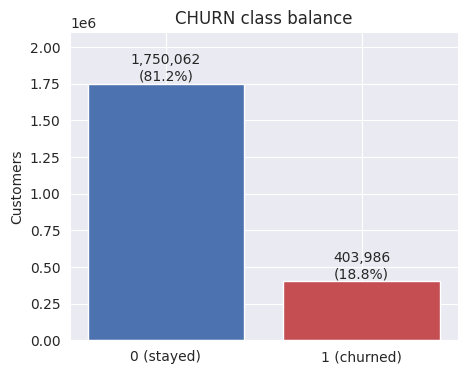

                train_pct_missing  test_pct_missing  churn_if_present  \
ZONE2                      93.648            93.666             0.053   
ZONE1                      92.121            92.144             0.045   
TIGO                       59.888            59.717             0.031   
DATA_VOLUME                49.230            49.205             0.073   
FREQ_TOP_PACK              41.902            41.770             0.040   
TOP_PACK                   41.902            41.770             0.040   
ORANGE                     41.561            41.362             0.040   
REGION                     39.428            39.389             0.018   
ON_NET                     36.521            36.439             0.052   
MONTANT                    35.131            35.003             0.050   
FREQUENCE_RECH             35.131            35.003             0.050   
FREQUENCE                  33.706            33.508             0.054   
REVENUE                    33.706            33.508

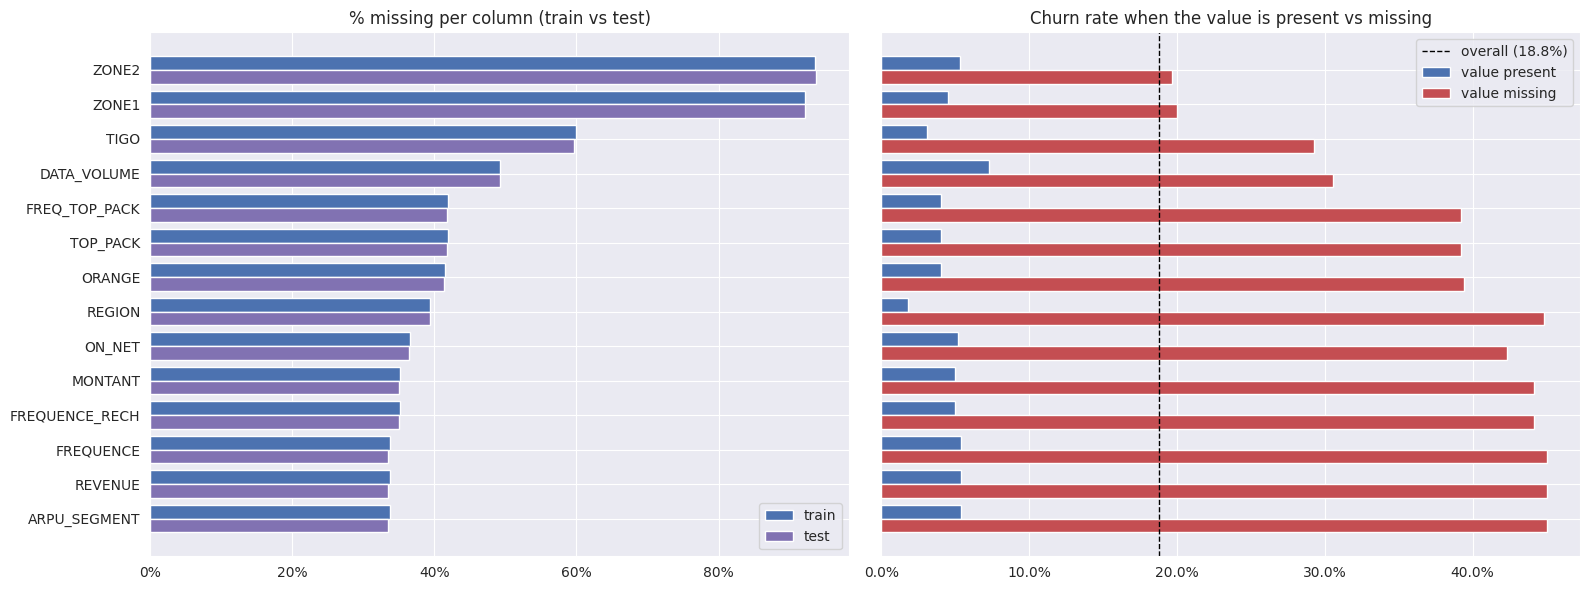

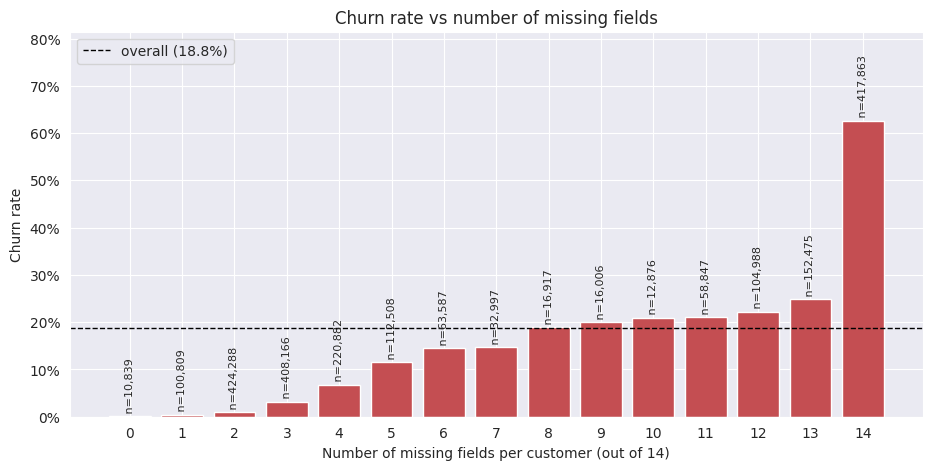

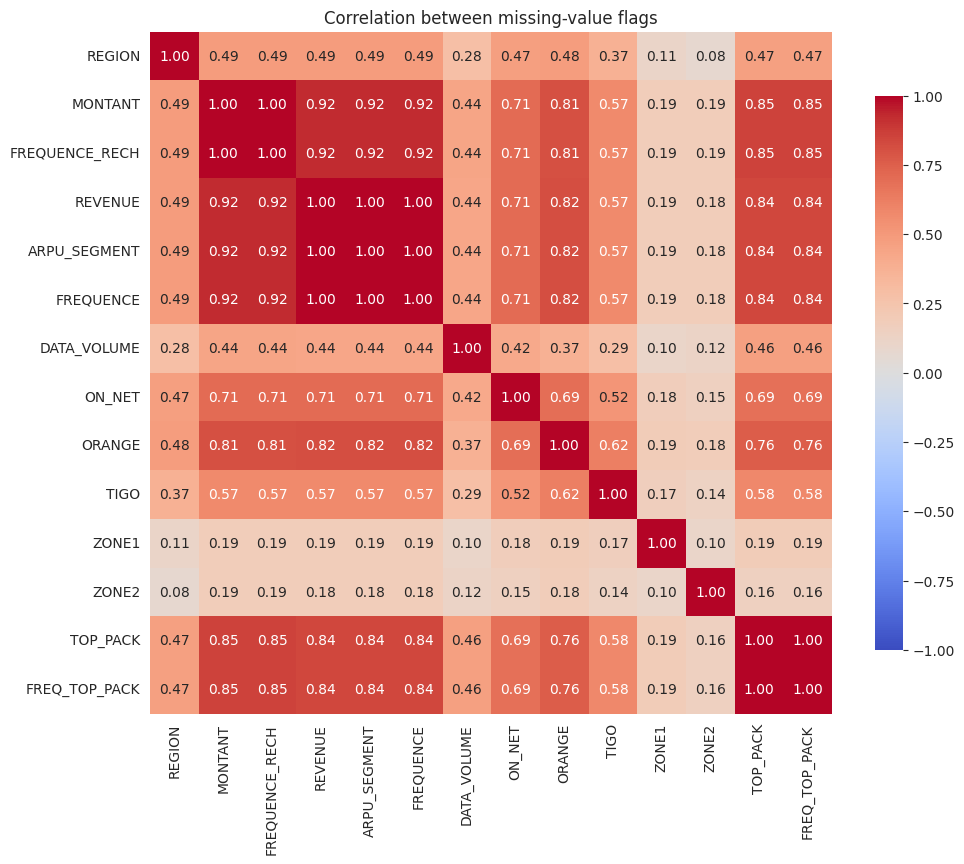

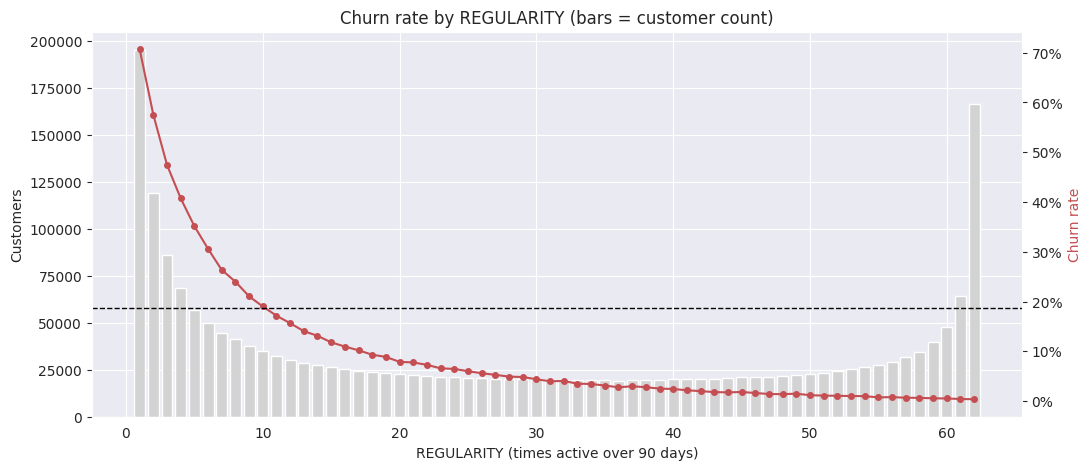

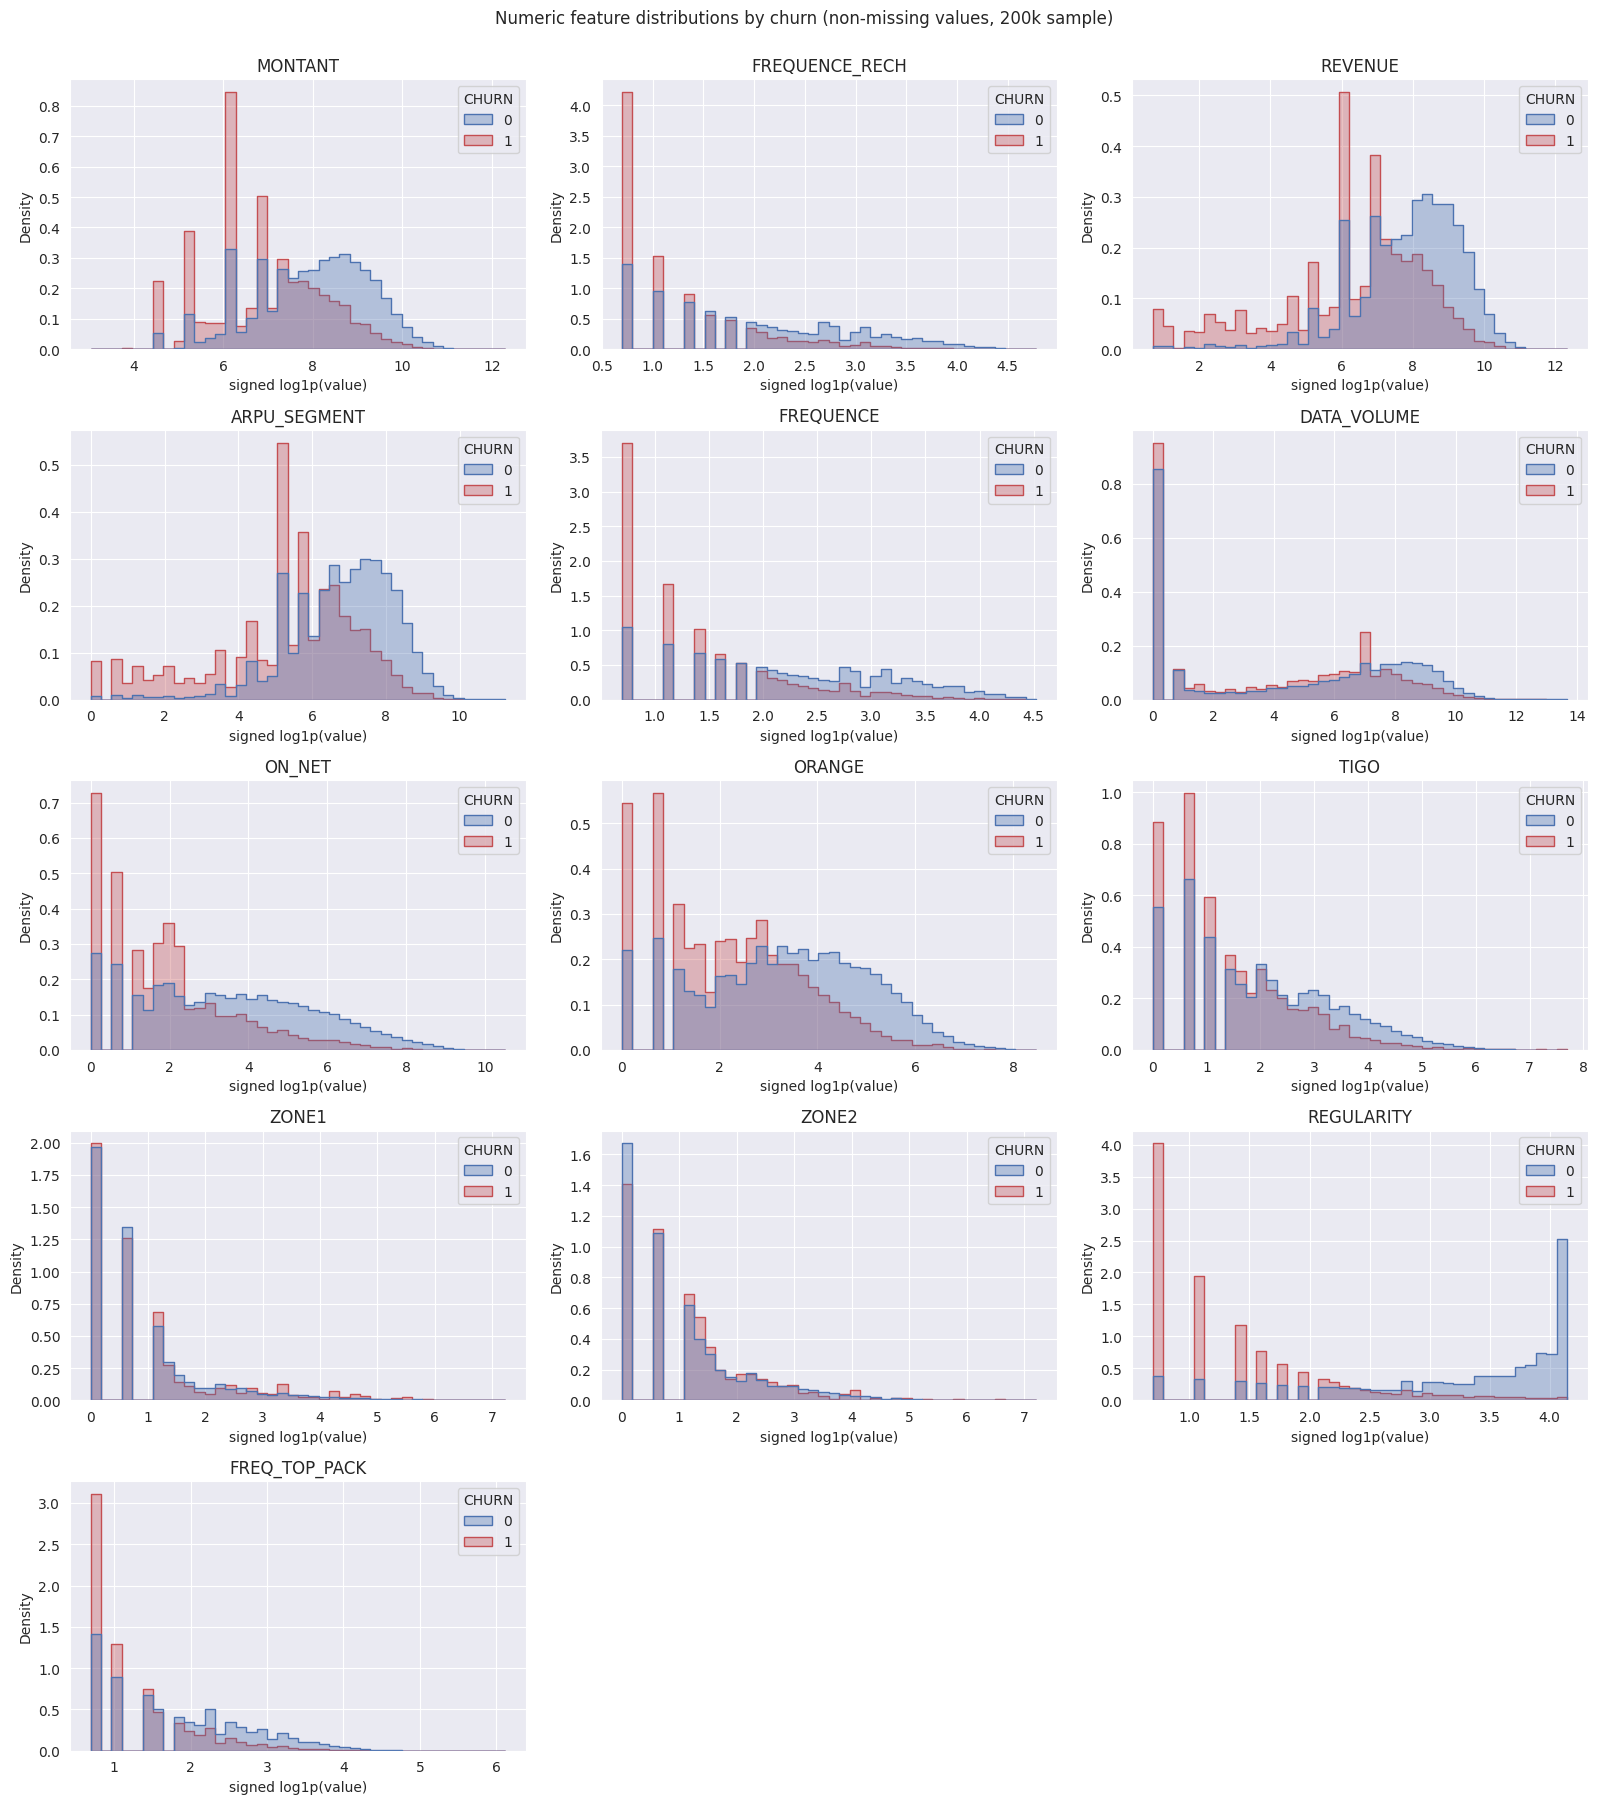

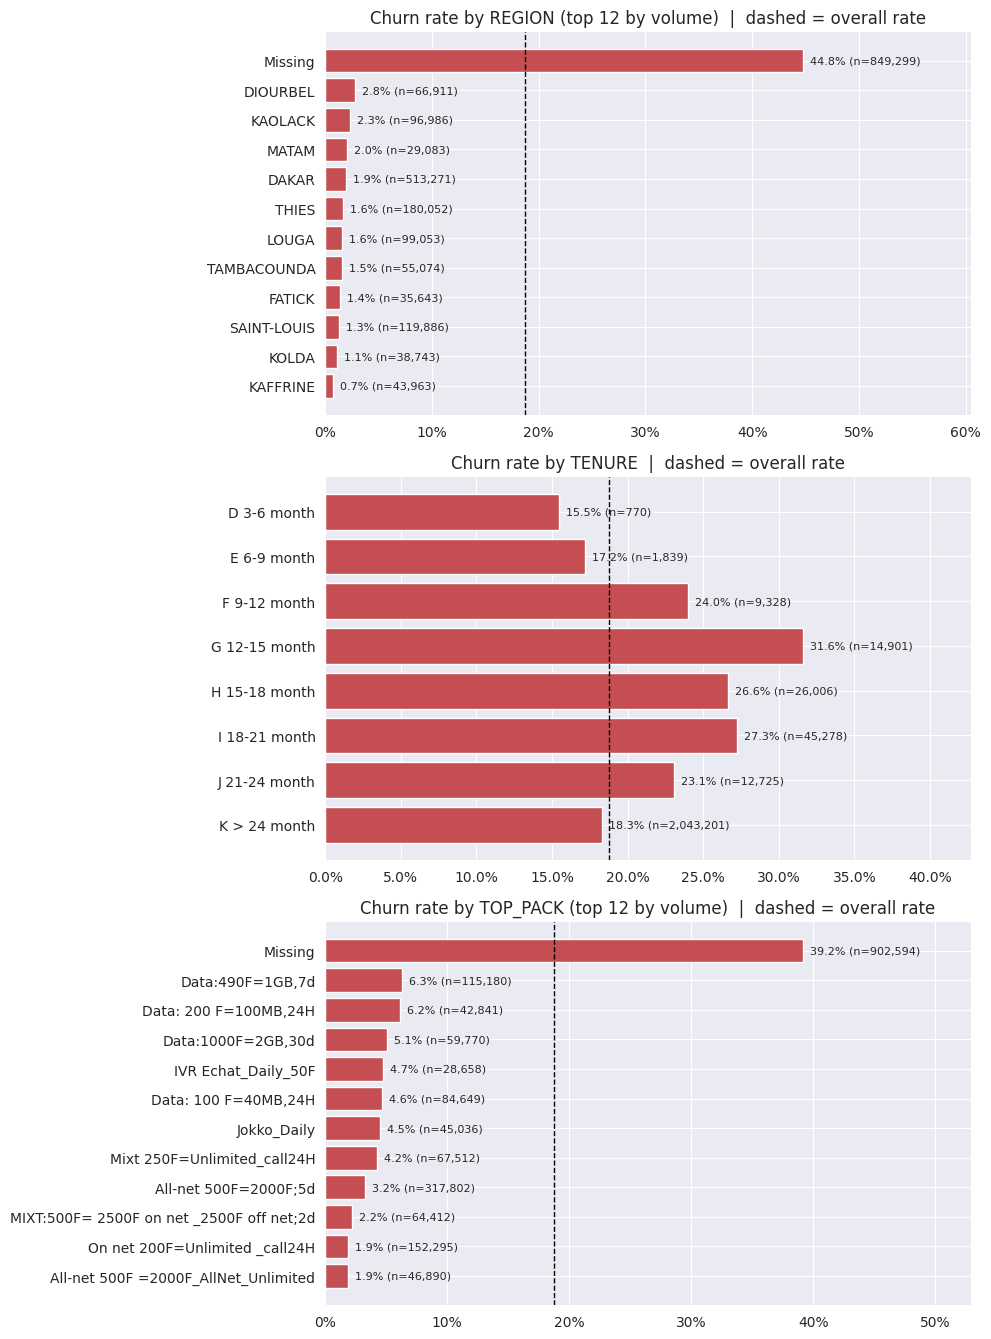

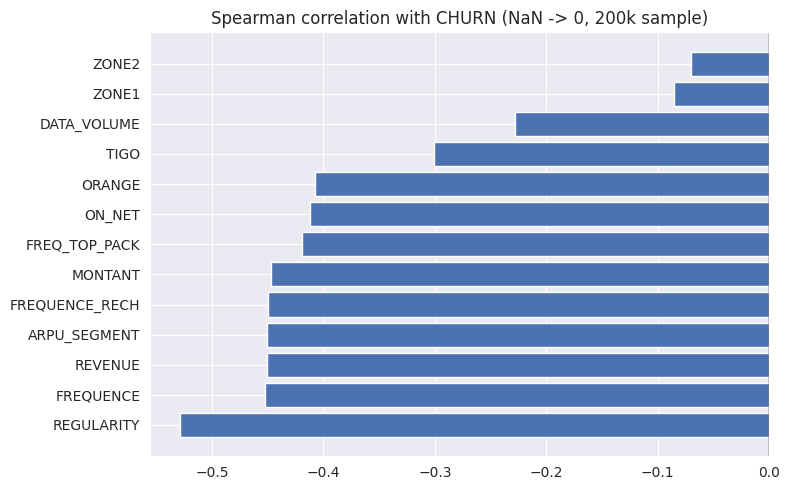

In [20]:
from matplotlib.ticker import PercentFormatter

raw = train.drop(columns=["user_id", "MRG"])
raw_test = test.drop(columns=["user_id", "MRG"])

feat_cols = [c for c in raw.columns if c != target]
raw_num = [c for c in feat_cols if pd.api.types.is_numeric_dtype(raw[c])]
raw_cat = [c for c in feat_cols if c not in raw_num]
na_cols = [c for c in feat_cols if raw[c].isna().any()]

base_rate = raw[target].mean()
samp = raw.sample(n=min(200_000, len(raw)), random_state=42)  # for the heavier plots
C0, C1 = "#4C72B0", "#C44E52"                                 # stayed / churned
# 1. Class balance
counts = raw[target].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["0 (stayed)", "1 (churned)"], counts.values, color=[C0, C1])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / len(raw):.1%})",
            ha="center", va="bottom")
ax.set_ylim(0, counts.max() * 1.2)
ax.set_ylabel("Customers")
ax.set_title("CHURN class balance")
plt.show()

# 2. Missingness: how much is missing (train vs test) and what it says about churn
miss = pd.DataFrame({
    "train_pct_missing": raw[na_cols].isna().mean() * 100,
    "test_pct_missing": raw_test[na_cols].isna().mean() * 100,
})
miss["churn_if_present"] = [raw.loc[raw[c].notna(), target].mean() for c in na_cols]
miss["churn_if_missing"] = [raw.loc[raw[c].isna(), target].mean() for c in na_cols]
miss = miss.sort_values("train_pct_missing", ascending=False)
print(miss.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
y_pos, h = np.arange(len(miss)), 0.4

axes[0].barh(y_pos - h / 2, miss["train_pct_missing"], h, color=C0, label="train")
axes[0].barh(y_pos + h / 2, miss["test_pct_missing"], h, color="#8172B2", label="test")
axes[0].xaxis.set_major_formatter(PercentFormatter(100))
axes[0].set_title("% missing per column (train vs test)")
axes[0].legend()

axes[1].barh(y_pos - h / 2, miss["churn_if_present"], h, color=C0, label="value present")
axes[1].barh(y_pos + h / 2, miss["churn_if_missing"], h, color=C1, label="value missing")
axes[1].axvline(base_rate, color="black", ls="--", lw=1, label=f"overall ({base_rate:.1%})")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Churn rate when the value is present vs missing")
axes[1].legend()

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(miss.index)
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()
# 3. How many fields are missing per customer vs churn rate
n_missing = raw[na_cols].isna().sum(axis=1)
mc = raw[target].groupby(n_missing).agg(churn_rate="mean", customers="size")

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(mc.index, mc["churn_rate"], color=C1)
ax.axhline(base_rate, color="black", ls="--", lw=1, label=f"overall ({base_rate:.1%})")
for xv, rate, cnt in zip(mc.index, mc["churn_rate"], mc["customers"]):
    ax.text(xv, rate, f" n={cnt:,}", ha="center", va="bottom", fontsize=8, rotation=90)
ax.set_ylim(0, mc["churn_rate"].max() * 1.3)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(mc.index)
ax.set_xlabel(f"Number of missing fields per customer (out of {len(na_cols)})")
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate vs number of missing fields")
ax.legend()
plt.show()
# 4. Do columns go missing together? (missingness co-occurrence)
flag_corr = raw[na_cols].isna().astype(np.int8).corr()
plt.figure(figsize=(11, 9))
sb.heatmap(flag_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
           square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation between missing-value flags")
plt.show()
# 5. REGULARITY vs churn rate (strongest single numeric signal)
reg = raw[target].groupby(raw["REGULARITY"]).agg(churn_rate="mean", customers="size")
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(reg.index, reg["customers"], color="lightgray")
ax1.set_xlabel("REGULARITY (times active over 90 days)")
ax1.set_ylabel("Customers")
ax2 = ax1.twinx()
ax2.plot(reg.index, reg["churn_rate"], color=C1, marker="o", ms=4)
ax2.axhline(base_rate, color="black", ls="--", lw=1)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_ylabel("Churn rate", color=C1)
ax2.grid(False)
ax1.set_title("Churn rate by REGULARITY (bars = customer count)")
plt.show()
# 6. Numeric distributions split by churn (non-missing values only)
# Signed log1p because these columns are heavily right-skewed
def signed_log1p(s):
    return np.sign(s) * np.log1p(np.abs(s))

n_cols = 3
n_rows = -(-len(raw_num) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.6 * n_rows))
axes = axes.ravel()
for ax, col in zip(axes, raw_num):
    d = samp[[col, target]].dropna()
    d = d.assign(**{col: signed_log1p(d[col])})
    sb.histplot(data=d, x=col, hue=target, bins=40, stat="density", common_norm=False,
                element="step", alpha=0.35, palette={0: C0, 1: C1}, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("signed log1p(value)")
for ax in axes[len(raw_num):]:
    ax.set_visible(False)
plt.suptitle("Numeric feature distributions by churn (non-missing values, 200k sample)", y=1.0)
plt.tight_layout()
plt.show()
# 7. Churn rate by categorical feature (NaN shown as its own category)
fig, axes = plt.subplots(len(raw_cat), 1, figsize=(10, 4.5 * len(raw_cat)))
for ax, col in zip(np.atleast_1d(axes), raw_cat):
    s = raw[col].fillna("Missing")
    stats = raw[target].groupby(s).agg(churn_rate="mean", customers="size")
    truncated = len(stats) > 12
    if truncated:
        stats = stats.nlargest(12, "customers")
    stats = stats.sort_index() if col == "TENURE" else stats.sort_values("churn_rate", ascending=False)

    ax.barh(range(len(stats)), stats["churn_rate"], color=C1)
    ax.set_yticks(range(len(stats)))
    ax.set_yticklabels(stats.index)
    ax.invert_yaxis()
    ax.axvline(base_rate, color="black", ls="--", lw=1)
    for i, (rate, cnt) in enumerate(zip(stats["churn_rate"], stats["customers"])):
        ax.text(rate, i, f"  {rate:.1%} (n={cnt:,})", va="center", fontsize=8)
    ax.set_xlim(0, stats["churn_rate"].max() * 1.35)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(f"Churn rate by {col}" + (" (top 12 by volume)" if truncated else "")
                 + "  |  dashed = overall rate")
plt.tight_layout()
plt.show()
# 8. Spearman correlation with churn (NaN -> 0, same treatment as the notebook)
sp = samp[raw_num].fillna(0).corrwith(samp[target], method="spearman").sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sp.index, sp.values, color=[C1 if v > 0 else C0 for v in sp.values])
ax.axvline(0, color="black", lw=1)
ax.set_title("Spearman correlation with CHURN (NaN -> 0, 200k sample)")
plt.tight_layout()
plt.show()

# Pipeline Setup
Prepare the original inputs, shared validation splits, and preprocessing before building the pipelines.

## Dataset and CV setup

In [21]:
from helpers import add_features, custom_make_pipeline, evaluate_pipeline
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, TargetEncoder, FunctionTransformer

target = "CHURN"

train_X = train.drop(columns=[target, "user_id", "MRG"])
train_y = train[target]
test_X = test.drop(columns=["user_id", "MRG"])

# reuse these splits for every model and selection comparison
groups = pd.util.hash_pandas_object(train_X, index=False)
cv_splits = list(GroupKFold(n_splits=5).split(train_X, train_y, groups))
cv = cv_splits

## Preprocessing

In [22]:
numeric_pipe = Pipeline([
    # !! REMOVED add_indicator=TRUE !!
    # Missingness indicators are added by the engineering step.
    ("impute", SimpleImputer(strategy="constant", fill_value=0)),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="None")),
    ("encode", TargetEncoder(target_type="binary", random_state=42)),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer(
    [
        # CHANGED num_cols_without_churn to make_column_selector(dtype_include="number") so that it automatically chooses number columns
        ("numeric", numeric_pipe, make_column_selector(dtype_include="number")),
        # same here, cat_cols -> make_column_selector(dtype_exclude="number")
        ("categorical", categorical_pipe, make_column_selector(dtype_exclude="number")),
    ],
    verbose_feature_names_out=False,
)

feature_pipeline = "passthrough"  # No feature selection for now, just use all features

`add_features` (in `helpers.py`) runs as the first pipeline step, on the raw columns *before* imputation. On top of the per-column `_IS_MISSING` flags, it adds two features. Both are row-wise calculations with nothing to fit, so they cannot leak information between training and validation folds.

**`INACTIVITY_COUNT`**: the number of columns that are missing, zero or `"None"` for each customer.

Why: the EDA showed that missing values are not random. Every column with NaNs was associated with churn, and for the categorical columns the signal came from the `"None"` category rather than the real values (Cramér's V). The fields also go missing in blocks: `MONTANT` and `FREQUENCE_RECH` have identical missing counts, as do `REVENUE`, `ARPU_SEGMENT` and `FREQUENCE`. This suggests they are all noisy views of one underlying state, a customer who has stopped being active. A single count summarises that state in one column, so a model can use "how much of this customer's activity is absent" without piecing it together from ~14 separate columns. It was also one of the four features selected by every selection method in every fold (see Feature Selection below).

Limitations: every column counts equally, and `ZONE1`/`ZONE2` are ~92-94% missing, so they add a near-constant offset. A genuine zero (e.g. no data usage) counts the same as a missing value, which matches our assumption that 0 means no activity.

**`AVERAGE_TOP_UP_AMOUNT`**: `MONTANT / FREQUENCE_RECH`, the average amount per refill. It is left as NaN, and so imputed to 0, when a customer has no refills (this also avoids dividing by zero).

Why: `MONTANT` and `FREQUENCE_RECH` are strongly correlated (≈0.8 in a Pearson check), because both mostly reflect how active a customer is. The ratio separates *how often* someone tops up from *how much* each top-up is. Frequent small top-ups and rare large ones are different behaviours, and neither raw column can express that alone.

Limitation: "no refills" appears as 0, but `INACTIVITY_COUNT` already captures that case.

# Feature Engineering

In [23]:
# ADDED feature engineering pipeline
# inside each custom_make_pipeline() call just add: feature_engineering=clone(feature_engineering)
feature_engineering = Pipeline([
    # add_features is in the helpers.py
    ("add_columns", FunctionTransformer(add_features)), 
])

# Checkpoint

In [24]:
from importlib import reload
import helpers

reload(helpers)
# Keep the same function object as the pipelines already in memory.
helpers.add_features = globals().get("add_features", helpers.add_features)
checkpoint = "experiments/notebook_results_v2.joblib"

def save_results():
    helpers.save_results(checkpoint, globals())

`globals().update(saved_results)` restores the saved variables into the notebook, replacing any variables with the same names. For example, `globals().update({"score": 0.92})` is the same as `score = 0.92`. 

In [25]:
globals().update(helpers.load_results(checkpoint))
cv = cv_splits  # Keep the later model comparisons on the restored splits too.

No checkpoint found. Run the experiments and call save_results().


# Feature Selection

Two questions:

1. Can we substantially reduce the number of features while maintaining all-columns prediction performance?
2. Do different selection procedures retain similar features?

We compare four approaches: a filter method (ANOVA), an embedded method (logistic regression with L1 regularization), and two wrapper methods: RFE with logistic regression and RFE with a decision tree.

Initially, we only considered logistic regression for RFE, but then realized that it shares the same limitation as L1 logistic regression. Both can miss nonlinear patterns unless suitable engineered features are provided. 

For example, logistic regression cannot directly represent “both very low and very high usage indicate risk, while moderate usage does not” using a single usage column. To account for that, we wanted to explore RFE with random forests, but after seeing how long our random-forest experiment took, we decided to use a single decision tree.

Every approach uses the same preprocessing, engineered features, validation splits and final `HistGradientBoostingClassifier`. 

Feature selection is fitted only on each fold's training rows. 

Since the number of features chosen by L1 logistic regression (those whose coefficient magnitudes exceed our threshold, 0.00001) depends on the regularization strength, we first need to choose a value of C that selects roughly the same number of features as the other methods, which in our case is half.

In [26]:
import sklearn
from sklearn.base import clone
from sklearn.feature_selection import (
    RFE, SelectPercentile, f_classif, SelectFromModel,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# FIX: l1_ratio=1 only means "L1" on sklearn >= 1.8. Older versions silently ignore it and
# fall back to L2, so no features were ever removed. Use the spelling that matches the version.
sk_version = tuple(int(p) for p in sklearn.__version__.split(".")[:2])
l1_kwargs = {"l1_ratio": 1} if sk_version >= (1, 8) else {"penalty": "l1"}

selectors = {
    "All columns": "passthrough",

    "RFE (logistic)": RFE(
        LogisticRegression(max_iter=2000),
        n_features_to_select=0.5,
        step=0.2,
    ),

    "RFE (decision tree)": RFE(
        DecisionTreeClassifier(
            max_depth=8, min_samples_leaf=100, random_state=42,
        ),
        n_features_to_select=0.5,
        step=0.2,
    ),

    "ANOVA": SelectPercentile(
        score_func=f_classif,
        percentile=50,
    ),

    "L1": SelectFromModel(
        LogisticRegression(
            solver="liblinear",
            C=0.001,  # the comparison below explains this choice.
            max_iter=2000,
            random_state=42,
            **l1_kwargs,  # L1 penalty (spelled differently before / after sklearn 1.8)
        ),
        threshold=1e-5,
    ),
}

## Choosing C for L1 selection

L1 Logistic Regression chooses features by reducing some logistic-regression coefficients to zero (removing them). Smaller C means stronger regularization and fewer selected features. We compare four C values, aiming to keep ~half the features while retaining prediction performance.

The earlier run recorded these results with the same validation splits and boosting settings:

| C | Mean AUC | Mean features kept |
| --- | --- | --- |
| 0.0001 | 0.92078 | 5.6 |
| 0.001 | 0.92144 | 14.4 |
| 0.01 | 0.92161 | 22.4 |
| 0.1 | 0.92146 | 24.4 |

In [27]:
pipelines = helpers.make_selection_pipelines(
    selectors, preprocessor, feature_engineering,
    HistGradientBoostingClassifier(
        max_iter=200, learning_rate=0.1,
        early_stopping=False, random_state=42,
    ),
)

l1_pipelines = {
    C: clone(pipelines["L1"]).set_params(features__estimator__C=C)
    for C in [0.0001, 0.001, 0.01, 0.1]
}
l1_summaries = globals().get("l1_summaries", {})
l1_feature_counts = globals().get("l1_feature_counts", {})

for C, pipeline in l1_pipelines.items():
    if C not in l1_summaries or C not in l1_feature_counts:
        summary, counts = helpers.evaluate_pipeline(
            pipeline, train_X, train_y, cv_splits
        )
        l1_summaries[C] = summary
        l1_feature_counts[C] = counts
        save_results()
    summary = l1_summaries[C]
    print(
        f"C={C}: AUC={summary['mean_auc']:.5f}, "
        f"features={summary['mean_columns_kept']:.1f}"
    )

l1_comparison = pd.DataFrame.from_dict(
    {C: l1_summaries[C] for C in l1_pipelines}, orient="index"
)
l1_comparison.index.name = "C"
display(l1_comparison[["mean_auc", "std_auc", "mean_columns_kept"]])
save_results()

# Sanity check: with a working L1 penalty, a stronger penalty (smaller C) must keep fewer columns.
if l1_comparison["mean_columns_kept"].nunique() == 1:
    print("WARNING: L1 kept the same number of columns for every C, so the L1 penalty "
          "is probably not being applied. Check the sklearn version and the selector in the cell above.")

Saved: pipelines, l1_summaries, l1_feature_counts, cv_splits
C=0.0001: AUC=0.92075, features=5.6
Saved: pipelines, l1_summaries, l1_feature_counts, cv_splits
C=0.001: AUC=0.92140, features=14.6
Saved: pipelines, l1_summaries, l1_feature_counts, cv_splits
C=0.01: AUC=0.92162, features=21.8
Saved: pipelines, l1_summaries, l1_feature_counts, cv_splits
C=0.1: AUC=0.92158, features=24.6


,mean_auc,std_auc,mean_columns_kept
C,,,
0.0001,0.920745,0.014049,5.6
0.0010,0.921398,0.013708,14.6
0.0100,0.921617,0.013654,21.8
0.1000,0.921577,0.013511,24.6


Saved: pipelines, l1_summaries, l1_feature_counts, l1_comparison, cv_splits


We choose C=0.001 for the combined comparison because it kept ~half the features.

In [28]:
selected_c = 0.001
selectors["L1"].set_params(estimator__C=selected_c)
pipelines["L1"] = clone(l1_pipelines[selected_c])

## Comparing all four selectors

We evaluate each selector against the all-columns baseline using the same final boosting model. 

In [29]:
score_rows = globals().get("score_rows", {})
# Older checkpoints stored scores as a list of rows with a "method" field.
if isinstance(score_rows, list):
    score_rows = {
        row["method"]: {key: value for key, value in row.items() if key != "method"}
        for row in score_rows
    }
feature_counts = globals().get("feature_counts", {})

# Keep completed results when moving from the old names to the clearer names.
for old_name, new_name in {"RFE": "RFE (logistic)", "Filter": "ANOVA"}.items():
    if old_name in score_rows and old_name in feature_counts:
        score_rows.setdefault(new_name, score_rows[old_name])
        feature_counts.setdefault(new_name, feature_counts[old_name])

# Reuse the exact C=0.001 result, including its fold scores and feature counts.
score_rows["L1"] = l1_summaries[selected_c]
feature_counts["L1"] = l1_feature_counts[selected_c]

for name, pipeline in pipelines.items():
    if name not in score_rows or name not in feature_counts:
        summary, counts = helpers.evaluate_pipeline(
            pipeline, train_X, train_y, cv_splits
        )
        score_rows[name] = summary
        feature_counts[name] = counts
        save_results()
    summary = score_rows[name]
    print(
        f"{name}: AUC={summary['mean_auc']:.5f}, "
        f"features={summary['mean_columns_kept']:.1f}"
    )

comparison = pd.DataFrame.from_dict(
    {name: score_rows[name] for name in pipelines}, orient="index"
)
comparison.index.name = "method"
comparison["auc_change_vs_all"] = (
    comparison["mean_auc"] - comparison.loc["All columns", "mean_auc"]
)
comparison = comparison.sort_values("mean_auc", ascending=False)
feature_choices = helpers.selection_frequencies(
    {name: feature_counts[name] for name in pipelines}, sort=False
)

display(comparison[
    ["mean_auc", "std_auc", "mean_columns_kept", "auc_change_vs_all"]
])
display(feature_choices)
save_results()

Saved: pipelines, score_rows, feature_counts, l1_summaries, l1_feature_counts, l1_comparison, cv_splits
All columns: AUC=0.92153, features=25.0
Saved: pipelines, score_rows, feature_counts, l1_summaries, l1_feature_counts, l1_comparison, cv_splits
RFE (logistic): AUC=0.92106, features=12.0
Saved: pipelines, score_rows, feature_counts, l1_summaries, l1_feature_counts, l1_comparison, cv_splits
RFE (decision tree): AUC=0.92143, features=12.0
Saved: pipelines, score_rows, feature_counts, l1_summaries, l1_feature_counts, l1_comparison, cv_splits
ANOVA: AUC=0.92107, features=12.0
L1: AUC=0.92140, features=14.6


,mean_auc,std_auc,mean_columns_kept,auc_change_vs_all
method,,,,
All columns,0.921528,0.013537,25.0,0.000000
RFE (decision tree),0.921434,0.013636,12.0,-0.000093
L1,0.921398,0.013708,14.6,-0.000129
ANOVA,0.921068,0.013870,12.0,-0.000460
RFE (logistic),0.921057,0.013930,12.0,-0.000471


,All columns,RFE (logistic),RFE (decision tree),ANOVA,L1
MONTANT,5,0,1,0,0
FREQUENCE_RECH,5,5,4,5,0
REVENUE,5,5,5,0,5
ARPU_SEGMENT,5,5,1,5,5
FREQUENCE,5,5,3,5,5
DATA_VOLUME,5,0,5,0,5
ON_NET,5,0,4,0,0
ORANGE,5,0,0,0,0
TIGO,5,0,0,0,0
ZONE1,5,0,0,0,0


Saved: pipelines, score_rows, feature_counts, comparison, feature_choices, l1_summaries, l1_feature_counts, l1_comparison, cv_splits


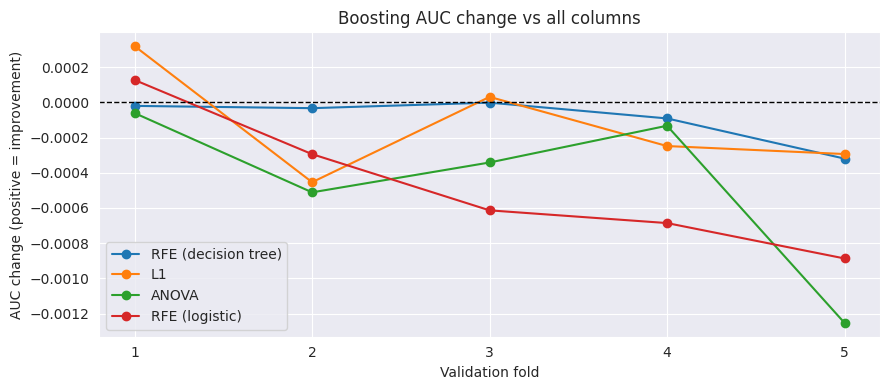

In [30]:
# Compare the AUC change within each shared validation fold, without refitting.
helpers.plot_auc_changes(comparison)

Selected by all 4 methods in every fold:
['REGULARITY', 'ON_NET_IS_MISSING', 'INACTIVITY_COUNT', 'REGION']


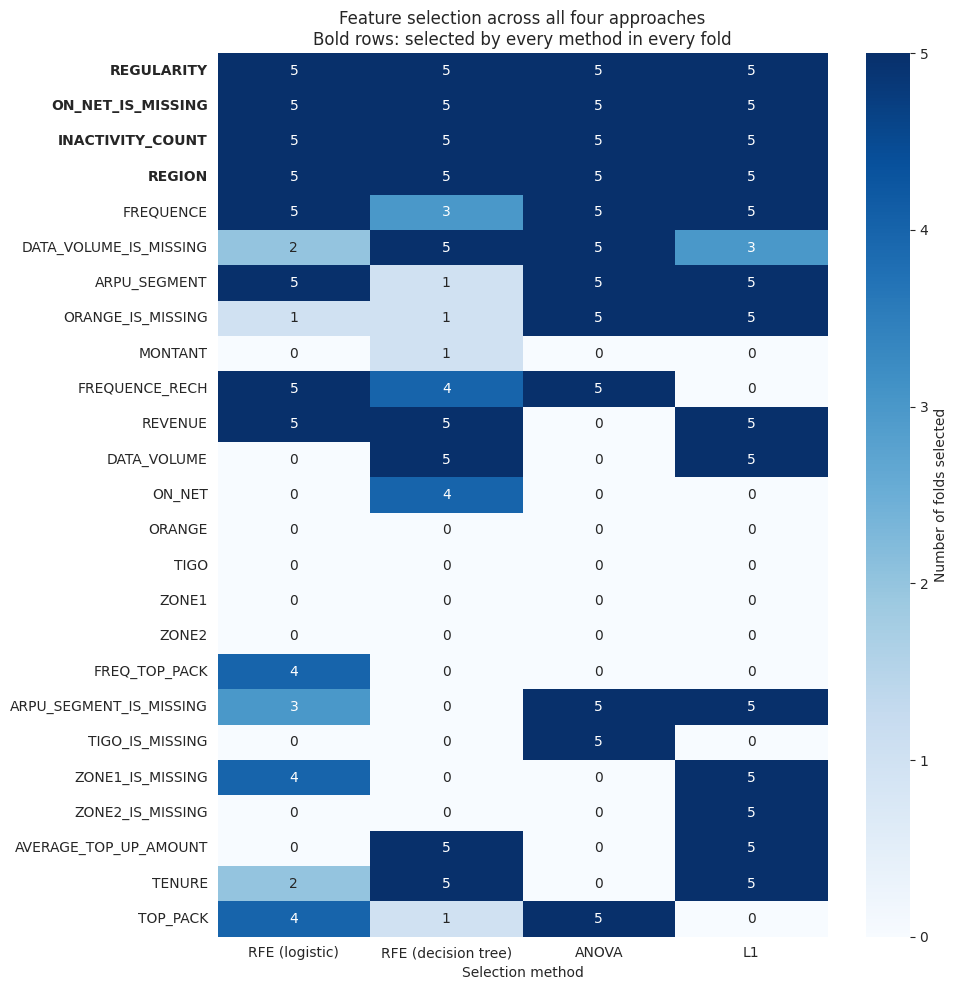

Saved: pipelines, score_rows, feature_counts, comparison, feature_choices, l1_summaries, l1_feature_counts, l1_comparison, all_selection_frequency, cv_splits


In [31]:
# Exclude the all-columns baseline when checking agreement between selectors.
all_selection_frequency = helpers.selection_frequencies(
    {name: feature_counts[name] for name in selectors if name != "All columns"},
    features=feature_choices.index,
)
helpers.plot_selection_agreement(
    all_selection_frequency, len(cv_splits),
    title="Feature selection across all four approaches",
)
save_results()

Number of folds selected, out of 5:


,Logistic regression,Decision tree,Tree minus logistic
DATA_VOLUME,0,5,5
AVERAGE_TOP_UP_AMOUNT,0,5,5
ON_NET,0,4,4
DATA_VOLUME_IS_MISSING,2,5,3
TENURE,2,5,3
MONTANT,0,1,1
REVENUE,5,5,0
ORANGE,0,0,0
TIGO,0,0,0
ZONE1,0,0,0


Selected by both RFE methods in every fold:
['REVENUE', 'REGULARITY', 'ON_NET_IS_MISSING', 'INACTIVITY_COUNT', 'REGION']


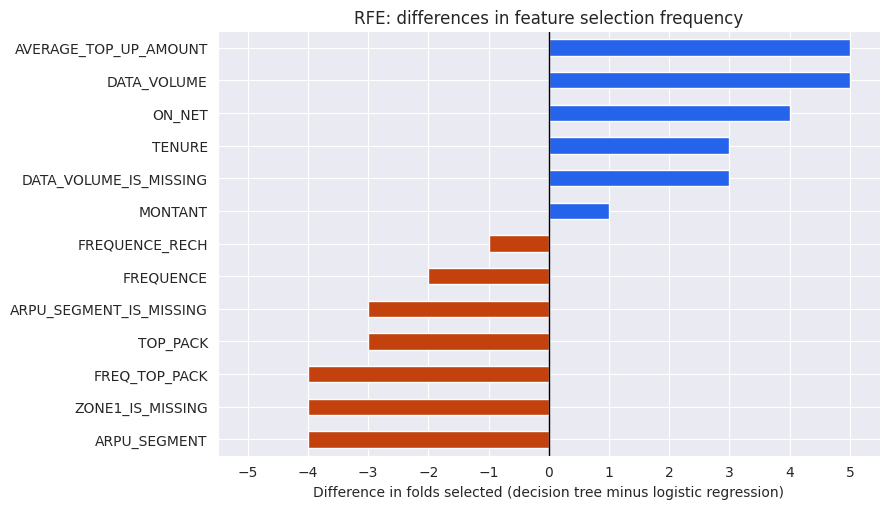

Saved: pipelines, score_rows, feature_counts, comparison, feature_choices, l1_summaries, l1_feature_counts, l1_comparison, rfe_feature_comparison, all_selection_frequency, cv_splits


In [32]:
# Equal selection counts can come from different folds.
rfe_feature_comparison = helpers.show_rfe_comparison(
    feature_counts["RFE (logistic)"],
    feature_counts["RFE (decision tree)"],
    len(cv_splits),
    features=feature_choices.index,
)
save_results()

REGULARITY, ON_NET_IS_MISSING, INACTIVITY_COUNT and REGION were consistently selected across all four methods and CV folds.

This suggests they might be useful candidates for further investigation by the service provider.

BUT, the selected features still depend on the model used. L1 and RFE with logistic regression both use a linear model, so adding decision-tree RFE lets us check whether their choices also hold for a model that can capture nonlinear patterns.

ANOVA removes roughly half the features with a negligible AUC decrease (0.921302 → 0.921238). It's fast and works well, so we choose it as the default feature-selection approach for subsequent experiments.

We keep the filter in the pipeline (as opposed to just passing the columns selected above) because the data, splits, or preprocessing might change later. This also ensures that feature selection is fitted separately within each training fold. When fitting the final model, we fit ANOVA again on the full training dataset.

To avoid repeating its work during model comparisons, we can enable pipeline caching (haven't done this yet though).

In [33]:
# Use the chosen default wherever the later model cells use feature_pipeline.
feature_pipeline = clone(selectors["ANOVA"])

# Testing Models
Some Hypothesis:
1. Based on distribution, it seems a linear model would work well by itself (LogisticRegression, DecisionTreeClassifier, RandomForestClassifier)
2. I suppose the best model will probably be boosting based method, probably XGBoost

## Simple Models

In [34]:
from sklearn.model_selection import cross_validate, cross_val_predict

# Universal switch: False skips EVERY fit_and_score call that passes a param_grid
# (Logistic Regression, Random Forest, Gradient Boosting, ...). Plain model runs are unaffected.
# Can be changed in any later cell; fit_and_score reads the current value on each call.
RUN_GRID_SEARCH = False

results = []
oof_probs = {}  # method -> out-of-fold P(churn) for every training row (used for the PR curve)

# precision / recall use the default 0.5 threshold; average_precision is the threshold-free area under the PR curve
SCORING = {
    "auc": "roc_auc",
    "ap": "average_precision",
    "precision": "precision",
    "recall": "recall",
}

# helper function - taking from Lab 5 and Lab 6
# CHANGED: also records average precision, precision and recall, and keeps out-of-fold
# probabilities in oof_probs for the PR curve. CV must be an explicit list of splits (as cv is).
def fit_and_score(method, model, CV, X_tr, y_tr, param_grid=None, store_oof=True):
    global results
    if param_grid is not None and not RUN_GRID_SEARCH:
        print(f"{method}: skipped (RUN_GRID_SEARCH = False)")
        return None  # nothing is fitted or recorded
    if param_grid is not None:
        search = GridSearchCV(model, param_grid, cv=CV, scoring=SCORING, refit="auc", n_jobs=5)
        search.fit(X_tr, y_tr)
        model = search.best_estimator_
        cvr, best = search.cv_results_, search.best_index_
        m = {k: cvr[f"mean_test_{k}"][best] for k in SCORING}
        cv_mean, cv_std = m["auc"], cvr["std_test_auc"][best]
        best_params = search.best_params_
        if store_oof:
            # GridSearchCV doesn't keep per-fold models, so this costs 5 extra fits
            oof_probs[method] = cross_val_predict(
                clone(model), X_tr, y_tr, cv=CV, method="predict_proba", n_jobs=5
            )[:, 1]
    else:
        cvres = cross_validate(
            model, X_tr, y_tr, cv=CV, scoring=SCORING,
            return_estimator=True, n_jobs=5,
        )
        m = {k: cvres[f"test_{k}"].mean() for k in SCORING}
        cv_mean, cv_std, best_params = m["auc"], cvres["test_auc"].std(), {}
        if store_oof:
            # reuse the fold models (no refit): predict each fold's held-out rows
            oof = np.zeros(len(y_tr))
            for est, (_, test_idx) in zip(cvres["estimator"], CV):
                oof[test_idx] = est.predict_proba(X_tr.iloc[test_idx])[:, 1]
            oof_probs[method] = oof
        model.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    results.append({
        "method": method,
        "cv_auc": cv_mean,
        "cv_auc_std": cv_std,
        "cv_ap": m["ap"],
        "cv_precision": m["precision"],
        "cv_recall": m["recall"],
        "train_auc": train_auc,
        "best_params": best_params,
    })
    print(f"{method}: | "
        f"CV AUC={cv_mean:.4f} ± {cv_std:.4f} | "
        f"CV AP={m['ap']:.4f} | "
        f"precision={m['precision']:.4f} | recall={m['recall']:.4f} | "
        f"train AUC={train_auc:.4f}")
    return model

In [35]:
# LogitsticRegresison - ETA 3 mins
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

log_reg = LogisticRegression(max_iter=2000)
model = custom_make_pipeline(
    preprocessor=clone(preprocessor),
    feature_engineering=clone(feature_engineering),
    feature_pipeline=feature_pipeline,
    classifier=log_reg
)
fit_and_score(
    'Logistic Regression', model, cv, train_X, train_y, 
)

log_reg_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}
fit_and_score(
    'Logistic Regression - Grid Search', model, cv, train_X, train_y, log_reg_grid
)

Logistic Regression: | CV AUC=0.9175 ± 0.0140 | CV AP=0.6340 | precision=0.6177 | recall=0.7263 | train AUC=0.9272
Logistic Regression - Grid Search: skipped (RUN_GRID_SEARCH = False)


In [36]:
# Takes wayyyyy too long for GridSearch, estimate 10 minutes for a non GridSearch run
from sklearn.ensemble import RandomForestClassifier

forest = custom_make_pipeline(
    preprocessor=clone(preprocessor),
    feature_engineering=clone(feature_engineering),
    feature_pipeline="passthrough",
    classifier=RandomForestClassifier(
        n_estimators=100,
        max_samples=0.25, # Each tree sees 25% of the entries (based on hashes)
        min_samples_leaf=100,
        random_state=42,
    ),
)

# forest_grid = {
#     "model__min_samples_leaf": [20, 50, 100],
#     "model__max_features": ["sqrt", 0.5],
# }

fit_and_score("Random Forest", forest, cv, train_X, train_y)
# fit_and_score("Random Forest - Grid Search", forest, cv, train_X, train_y, forest_grid)

Random Forest: | CV AUC=0.9208 ± 0.0126 | CV AP=0.6431 | precision=0.6662 | recall=0.5877 | train AUC=0.9312


Pipeline(steps=[('engineer',
                 Pipeline(steps=[('add_columns',
                                  FunctionTransformer(func=<function add_features at 0x7eec1d48f740>))])),
                ('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector obje...
                                                                   SimpleImputer(fill_value='None',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   TargetEncoder(random_state=42,
                                                                                 target_type='binary')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7eec32915fd0>)],
                                   verbose_feature_names_out=False)),
                ('features', 'passthrough'),
                ('model',
                 RandomForestClassifier(max_samples=0.25, min_samples_leaf=100,
                                        random_state=42))])

In [37]:
from sklearn.ensemble import HistGradientBoostingClassifier # A much faster variant of GradientBoostingClassifier - Took 6 minutes

boost = custom_make_pipeline(
    preprocessor=clone(preprocessor),
    feature_engineering=clone(feature_engineering),
    feature_pipeline=feature_pipeline,
    classifier=HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        early_stopping=False,
        random_state=42,
    ),
)

boost_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [31, 63], 
}

fit_and_score("Histogram Gradient Boosting", boost, cv, train_X, train_y)
fit_and_score("Histogram Gradient Boosting - Grid Search", boost, cv, train_X, train_y, boost_grid)

Histogram Gradient Boosting: | CV AUC=0.9211 ± 0.0124 | CV AP=0.6408 | precision=0.6593 | recall=0.6073 | train AUC=0.9312
Histogram Gradient Boosting - Grid Search: skipped (RUN_GRID_SEARCH = False)


In [38]:
results

[{'method': 'Logistic Regression',
  'cv_auc': np.float64(0.9175296657321581),
  'cv_auc_std': np.float64(0.013951928151715197),
  'cv_ap': np.float64(0.6340442273319454),
  'cv_precision': np.float64(0.6177236317355325),
  'cv_recall': np.float64(0.7262716285099703),
  'train_auc': np.float64(0.9271761592740504),
  'best_params': {}},
 {'method': 'Random Forest',
  'cv_auc': np.float64(0.9207795147554256),
  'cv_auc_std': np.float64(0.01257184366367407),
  'cv_ap': np.float64(0.6430676440872446),
  'cv_precision': np.float64(0.6662248961173657),
  'cv_recall': np.float64(0.5876760924397527),
  'train_auc': np.float64(0.9312002721669486),
  'best_params': {}},
 {'method': 'Histogram Gradient Boosting',
  'cv_auc': np.float64(0.921066393228581),
  'cv_auc_std': np.float64(0.012404847073258172),
  'cv_ap': np.float64(0.6407921740824244),
  'cv_precision': np.float64(0.659301601640115),
  'cv_recall': np.float64(0.6072983842213757),
  'train_auc': np.float64(0.9311842048979115),
  'best_p

,method,cv_auc,cv_auc_std,cv_ap,cv_precision,cv_recall,train_auc
0,Logistic Regression,0.9175,0.0140,0.6340,0.6177,0.7263,0.9272
1,Random Forest,0.9208,0.0126,0.6431,0.6662,0.5877,0.9312
2,Histogram Gradient Boosting,0.9211,0.0124,0.6408,0.6593,0.6073,0.9312


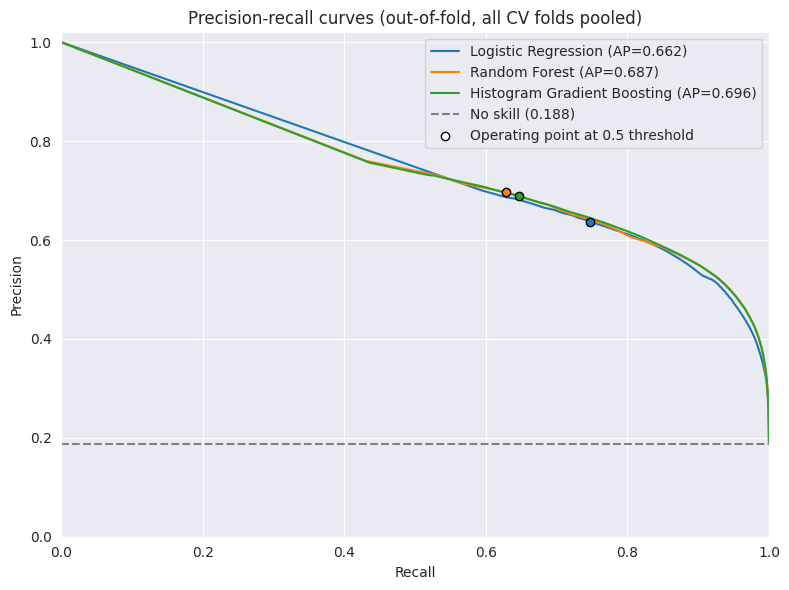

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from IPython.display import display

# Nothing to show if the model cells haven't run since fit_and_score was (re)defined,
# because redefining it resets results and oof_probs.
if not results:
    raise RuntimeError("`results` is empty - run the model cells (54-56) first, then re-run this cell.")

# 1) All metrics side by side (best_params dropped for readability)
display(pd.DataFrame(results).drop(columns="best_params", errors="ignore").round(4))

# 2) Precision-recall curves from out-of-fold predictions
def plot_pr_curves(oof_probs, y_true, threshold=0.5):
    y_true = np.asarray(y_true)
    base_rate = y_true.mean()  # a model with no skill sits at this precision
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, p in oof_probs.items():
        precision, recall, _ = precision_recall_curve(y_true, p)
        ap = average_precision_score(y_true, p)
        keep = np.linspace(0, len(precision) - 1, 2000).astype(int)  # thin millions of points for plotting
        line, = ax.plot(recall[keep], precision[keep], label=f"{name} (AP={ap:.3f})")
        # operating point at the default threshold, i.e. the precision/recall printed above
        pred = p >= threshold
        tp = (pred & (y_true == 1)).sum()
        ax.scatter(tp / y_true.sum(), tp / max(pred.sum(), 1), color=line.get_color(),
                   edgecolor="black", zorder=3)
    ax.axhline(base_rate, color="gray", ls="--", label=f"No skill ({base_rate:.3f})")
    ax.scatter([], [], color="white", edgecolor="black", label=f"Operating point at {threshold} threshold")
    ax.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1.02),
           title="Precision-recall curves (out-of-fold, all CV folds pooled)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

if oof_probs:
    plot_pr_curves(oof_probs, train_y)
else:
    print("No out-of-fold predictions stored (models were run with store_oof=False), so no PR curve.")

In [40]:
# =====================================================================
# ABLATION: does class weighting actually matter?
# Same pipeline and the SAME fixed hyperparameters as the plain "Histogram Gradient Boosting"
# run. The ONLY change is class_weight="balanced". 5-fold grouped CV, no grid search.
#   plain (unweighted)  vs  this model   -> effect of weighting alone
#   this model          vs  final model  -> effect of grid search on top
# =====================================================================
ABLATION_NAME = "HGB - class weighted (no grid search)"

boost_weighted_fixed = clone(boost).set_params(model__class_weight="balanced")

# param_grid is None, so no grid search runs (RUN_GRID_SEARCH is irrelevant here)
ablation_model = fit_and_score(ABLATION_NAME, boost_weighted_fixed, cv, train_X, train_y)

HGB - class weighted (no grid search): | CV AUC=0.9213 ± 0.0121 | CV AP=0.6436 | precision=0.5247 | recall=0.9112 | train AUC=0.9304


No out-of-fold predictions for: ['HGB - class weighted + grid search (final)'] - run those model cells first.


,auc,auc_std,ap,ap_std,precision@0.5,recall@0.5,best_f1,best_f1_threshold,precision@60%recall,precision@75%recall
Histogram Gradient Boosting,0.9211,0.0139,0.6408,0.0865,0.6885,0.6468,0.6974,0.3537,0.6957,0.6408
HGB - class weighted (no grid search),0.9213,0.0135,0.6436,0.0836,0.5332,0.9179,0.6974,0.7002,0.7066,0.6437


,comparison,metric,mean_diff,std_of_diff,folds_improved
0,weighting alone (weighted - plain),AUC,0.00021,0.00046,3/5
1,weighting alone (weighted - plain),AP,0.00283,0.00419,3/5


At recall 0.918: weighted model precision 0.5332 | plain model (threshold lowered to match) 0.5312


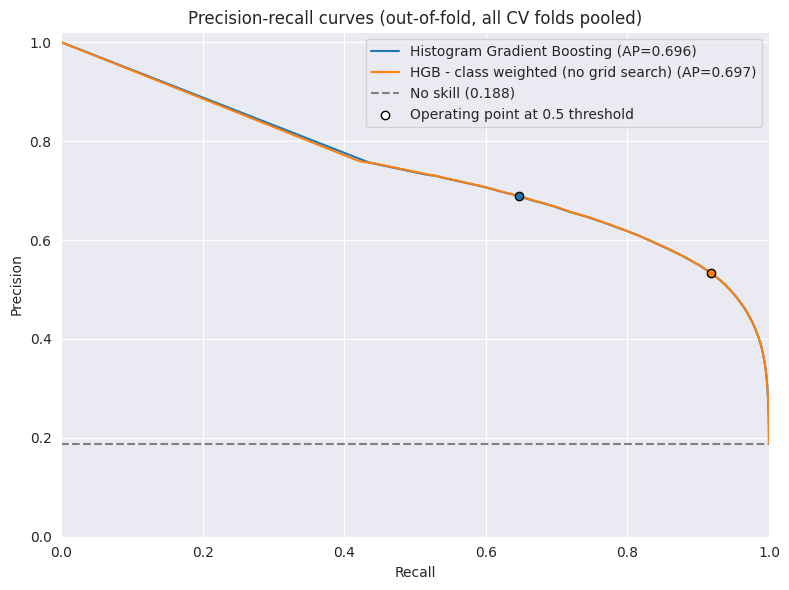

In [41]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, precision_score, recall_score, f1_score)

BASE_NAME = "Histogram Gradient Boosting"      # plain: unweighted, default hyperparameters
ABLATION_NAME = globals().get("ABLATION_NAME", "HGB - class weighted (no grid search)")
FINAL_NAME = globals().get("FINAL_NAME", "HGB - class weighted + grid search (final)")
names = [n for n in [BASE_NAME, ABLATION_NAME, FINAL_NAME] if n in oof_probs]
missing = [n for n in [BASE_NAME, ABLATION_NAME, FINAL_NAME] if n not in oof_probs]
if missing:
    print("No out-of-fold predictions for:", missing, "- run those model cells first.")

y_arr = np.asarray(train_y)

def per_fold(metric, name):
    """Metric on each CV fold's held-out rows, from the stored out-of-fold predictions."""
    return np.array([metric(y_arr[te], oof_probs[name][te]) for _, te in cv])

def precision_at_recall(y, p, target):
    prec, rec, _ = precision_recall_curve(y, p)
    return prec[rec >= target].max()

# 1) Side by side. AUC / AP are threshold-free (ranking quality); the rest depend on the threshold.
auc_f = {n: per_fold(roc_auc_score, n) for n in names}
ap_f = {n: per_fold(average_precision_score, n) for n in names}
rows = {}
for n in names:
    p = oof_probs[n]
    prec, rec, thr = precision_recall_curve(y_arr, p)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    rows[n] = {
        "auc": auc_f[n].mean(), "auc_std": auc_f[n].std(ddof=1),
        "ap": ap_f[n].mean(), "ap_std": ap_f[n].std(ddof=1),
        "precision@0.5": precision_score(y_arr, p >= 0.5),
        "recall@0.5": recall_score(y_arr, p >= 0.5),
        "best_f1": f1.max(), "best_f1_threshold": thr[f1.argmax()],
        "precision@60%recall": precision_at_recall(y_arr, p, 0.60),
        "precision@75%recall": precision_at_recall(y_arr, p, 0.75),
    }
display(pd.DataFrame(rows).T.round(4))

# 2) Paired per-fold differences: is the gap bigger than fold-to-fold noise?
pairs = {"weighting alone (weighted - plain)": (BASE_NAME, ABLATION_NAME),
         "grid search on top (final - weighted)": (ABLATION_NAME, FINAL_NAME)}
diff_rows = []
for label, (a, b) in pairs.items():
    if a in oof_probs and b in oof_probs:
        for metric, f in [("AUC", auc_f), ("AP", ap_f)]:
            d = f[b] - f[a]
            diff_rows.append({"comparison": label, "metric": metric, "mean_diff": d.mean(),
                              "std_of_diff": d.std(ddof=1), "folds_improved": f"{(d > 0).sum()}/{len(d)}"})
display(pd.DataFrame(diff_rows).round(5))

# 3) Is weighting more than a threshold shift? Give the plain model the SAME recall the weighted
#    model gets at 0.5 (by lowering its threshold) and compare precision at that recall.
if BASE_NAME in oof_probs and ABLATION_NAME in oof_probs:
    r_w = recall_score(y_arr, oof_probs[ABLATION_NAME] >= 0.5)
    p_w = precision_score(y_arr, oof_probs[ABLATION_NAME] >= 0.5)
    p_plain = precision_at_recall(y_arr, oof_probs[BASE_NAME], r_w)
    print(f"At recall {r_w:.3f}: weighted model precision {p_w:.4f} | plain model (threshold lowered to match) {p_plain:.4f}")

# 4) PR curves (needs plot_pr_curves from the PR-curve cell above)
plot_pr_curves({n: oof_probs[n] for n in names}, train_y)

# Final Model
Histogram Gradient Boosting had the highest CV AUC (0.9211), and AUC is the competition metric. Its lead over Random Forest (0.9208) is far smaller than the fold-to-fold spread (±0.012), so the two are effectively tied. We pick gradient boosting because it is faster and is the model used throughout feature selection.

For the final model we add class weighting (`class_weight="balanced"`, since only ~19% of customers churn), tune the learning rate and tree size with grid search CV, and refit the winning configuration on all training rows. No rows are held out for this final fit, so the honest performance estimate is the grid search's out-of-fold score. Scores on the training rows themselves are optimistic and shown for reference only.

In [42]:
# FINAL MODEL: Histogram Gradient Boosting + class weights + grid search CV,
# then refit on ALL training rows (GridSearchCV's refit step does this).
FINAL_NAME = "HGB - class weighted + grid search (final)"

# Same pipeline as `boost`; the only change is class weighting
boost_weighted = clone(boost).set_params(model__class_weight="balanced")

final_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [31, 63],
    "model__min_samples_leaf": [20, 100, 300],     # larger = smoother trees, helps with many noisy duplicate rows  
}

from sklearn.model_selection import ParameterGrid
n_configs = len(ParameterGrid(final_grid))
print(f"{n_configs} configurations x 5 folds = {n_configs * 5} fits")

# Force grid search ON for this cell only, then put the global switch back
_previous_switch = RUN_GRID_SEARCH
RUN_GRID_SEARCH = True
try:
    # Out-of-fold metrics come from the grid search's CV (honest estimate);
    # the returned model is the best configuration refit on ALL of train_X
    final_model = fit_and_score(FINAL_NAME, boost_weighted, cv, train_X, train_y, final_grid)
finally:
    RUN_GRID_SEARCH = _previous_switch

print("\nBest params:", results[-1]["best_params"])

12 configurations x 5 folds = 60 fits
HGB - class weighted + grid search (final): | CV AUC=0.9219 ± 0.0122 | CV AP=0.6470 | precision=0.5259 | recall=0.9111 | train AUC=0.9316

Best params: {'model__learning_rate': 0.1, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 300}


,cv_auc,cv_auc_std,cv_ap,cv_precision,cv_recall
method,,,,,
Histogram Gradient Boosting,0.9211,0.0124,0.6408,0.6593,0.6073
HGB - class weighted + grid search (final),0.9219,0.0122,0.6470,0.5259,0.9111



In-sample (all 2,154,048 training rows) | AUC=0.9316 | AP=0.7016
              precision    recall  f1-score   support

           0      0.978     0.813     0.888   1750062
           1      0.533     0.922     0.675    403986

    accuracy                          0.834   2154048
   macro avg      0.756     0.868     0.782   2154048
weighted avg      0.895     0.834     0.848   2154048



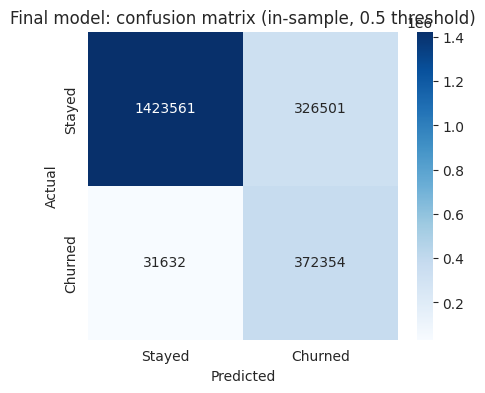

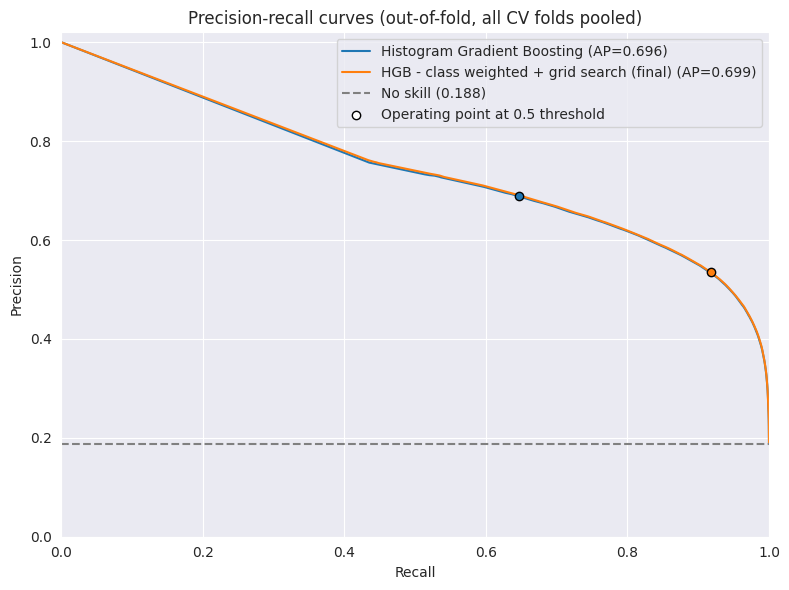

In [43]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)

# 1) Honest comparison: out-of-fold (CV) metrics, unweighted baseline vs final model
baseline_name = "Histogram Gradient Boosting"
comparison = (
    pd.DataFrame(results)
    .drop_duplicates("method", keep="last")
    .set_index("method")
    .loc[[baseline_name, FINAL_NAME], ["cv_auc", "cv_auc_std", "cv_ap", "cv_precision", "cv_recall"]]
    .round(4)
)
display(comparison)

# 2) Final model on ALL training rows. These rows were used for fitting,
#    so treat these numbers as optimistic reference only.
p_all = final_model.predict_proba(train_X)[:, 1]
pred_all = (p_all >= 0.5).astype(int)
print(f"\nIn-sample (all {len(train_y):,} training rows) | "
      f"AUC={roc_auc_score(train_y, p_all):.4f} | AP={average_precision_score(train_y, p_all):.4f}")
print(classification_report(train_y, pred_all, digits=3))

cm = confusion_matrix(train_y, pred_all)
plt.figure(figsize=(5, 4))
sb.heatmap(cm, annot=True, fmt="d", cmap="Blues",
           xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
plt.title("Final model: confusion matrix (in-sample, 0.5 threshold)")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

# 3) PR curves (out-of-fold): needs plot_pr_curves from the PR-curve cell above
plot_pr_curves({k: oof_probs[k] for k in [baseline_name, FINAL_NAME] if k in oof_probs}, train_y)

# Model Interpretation

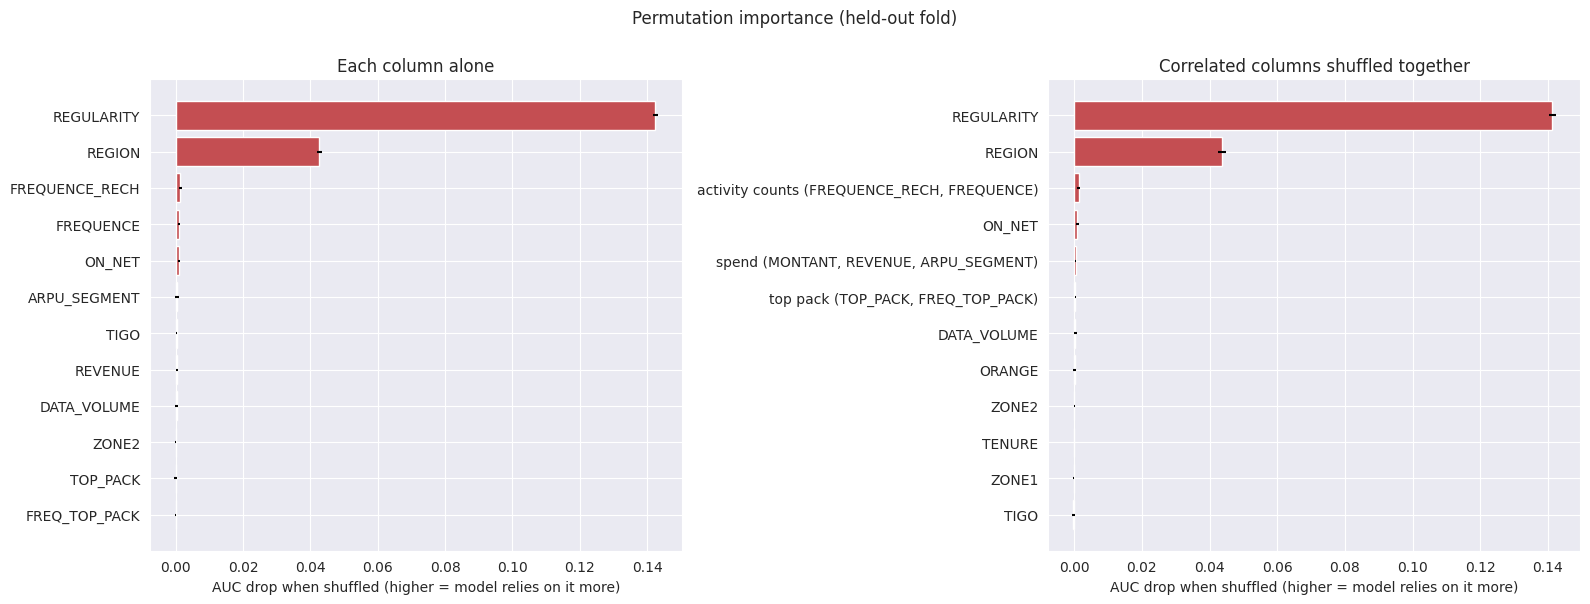

,auc_drop,std,columns
REGULARITY,0.1413,0.0010,REGULARITY
REGION,0.0436,0.0012,REGION
"activity counts (FREQUENCE_RECH, FREQUENCE)",0.0013,0.0004,"FREQUENCE_RECH, FREQUENCE"
ON_NET,0.0009,0.0004,ON_NET
"spend (MONTANT, REVENUE, ARPU_SEGMENT)",0.0004,0.0003,"MONTANT, REVENUE, ARPU_SEGMENT"
"top pack (TOP_PACK, FREQ_TOP_PACK)",0.0004,0.0002,"TOP_PACK, FREQ_TOP_PACK"
DATA_VOLUME,0.0003,0.0004,DATA_VOLUME
ORANGE,0.0001,0.0004,ORANGE
ZONE2,0.0000,0.0001,ZONE2
TENURE,0.0000,0.0000,TENURE


In [44]:
# =====================================================================
# 1. PERMUTATION IMPORTANCE  (global ranking)
# Question: how much does AUC drop if a column is scrambled?
# Honest version: the final configuration is refit on 4 CV folds' worth of rows
# and scored on the 5th, so the ranking reflects generalisation, not memorisation.
# =====================================================================
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

tr_idx, va_idx = cv[0]
interp_model = clone(final_model).fit(train_X.iloc[tr_idx], train_y.iloc[tr_idx])  # one extra fit

rng = np.random.default_rng(42)
va_idx = rng.choice(va_idx, size=min(60_000, len(va_idx)), replace=False)
X_va, y_va = train_X.iloc[va_idx], train_y.iloc[va_idx]

def permutation_importance_groups(model, X, y, groups, n_repeats=5, seed=42):
    """AUC drop when each group of columns is shuffled (all columns of a group together)."""
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, model.predict_proba(X)[:, 1])
    rows = {}
    for name, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            order = rng.permutation(len(X))
            for c in cols:                       # same row order for every column in the group
                Xp[c] = X[c].to_numpy()[order]   # per-column assignment keeps each column's dtype
            drops.append(base - roc_auc_score(y, model.predict_proba(Xp)[:, 1]))
        rows[name] = {"auc_drop": np.mean(drops), "std": np.std(drops), "columns": ", ".join(cols)}
    out = pd.DataFrame(rows).T.astype({"auc_drop": float, "std": float})
    return out.sort_values("auc_drop", ascending=False)

# (a) every column on its own
singles = {c: [c] for c in X_va.columns}
perm_single = permutation_importance_groups(interp_model, X_va, y_va, singles)

# (b) near-duplicate columns shuffled together (each alone looks unimportant because
#     its twin still carries the signal)
correlated = {
    "spend (MONTANT, REVENUE, ARPU_SEGMENT)": ["MONTANT", "REVENUE", "ARPU_SEGMENT"],
    "activity counts (FREQUENCE_RECH, FREQUENCE)": ["FREQUENCE_RECH", "FREQUENCE"],
    "top pack (TOP_PACK, FREQ_TOP_PACK)": ["TOP_PACK", "FREQ_TOP_PACK"],
}
in_group = {c for cols in correlated.values() for c in cols}
grouped = {**correlated, **{c: [c] for c in X_va.columns if c not in in_group}}
perm_grouped = permutation_importance_groups(interp_model, X_va, y_va, grouped)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, table, title in [(axes[0], perm_single, "Each column alone"),
                         (axes[1], perm_grouped, "Correlated columns shuffled together")]:
    top = table.head(12)
    ax.barh(top.index, top["auc_drop"], xerr=top["std"], color="#C44E52")
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("AUC drop when shuffled (higher = model relies on it more)")
plt.suptitle("Permutation importance (held-out fold)", y=1.0)
plt.tight_layout()
plt.show()

display(perm_grouped.head(12).round(4))

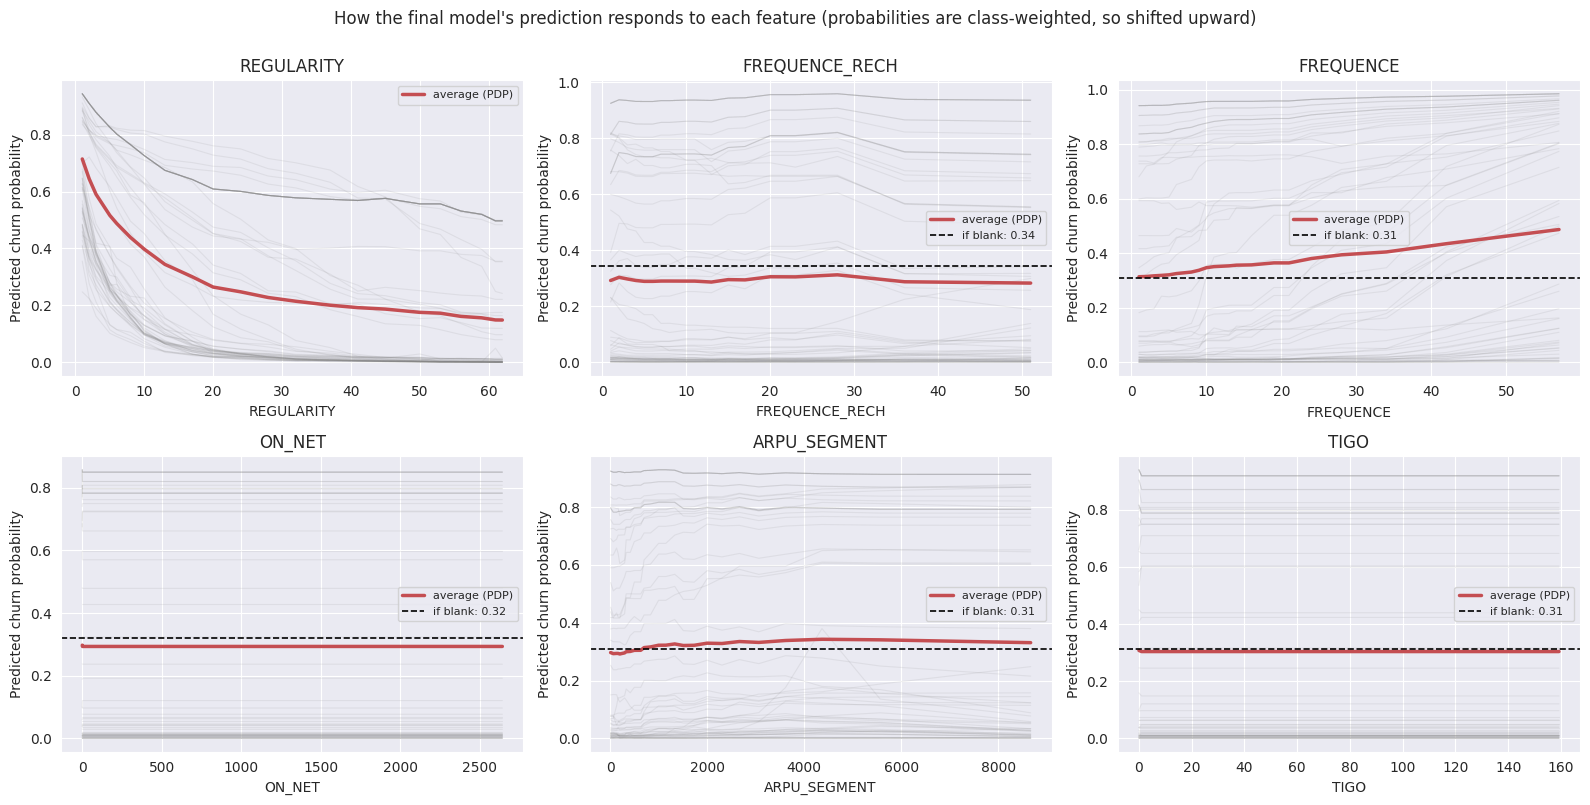

In [45]:
# =====================================================================
# 2. PARTIAL DEPENDENCE + ICE  (the shape of f(x_i))
# Question: as one column changes, how does the model's predicted churn move?
# Bold line = average over customers (PDP); faint lines = individual customers (ICE).
# Dashed line = what the model predicts if the field is BLANK (missingness is a signal here).
# Needs perm_single from the permutation cell above.
# =====================================================================
X_pdp = train_X.sample(n=min(20_000, len(train_X)), random_state=42)

def pdp_ice(model, X, col, n_grid=25, n_ice=60):
    grid = np.unique(np.quantile(X[col].dropna(), np.linspace(0.02, 0.98, n_grid)))
    means, ice = [], []
    for v in grid:
        Xg = X.copy()
        Xg[col] = v                                   # everyone gets the same value of `col`
        p = model.predict_proba(Xg)[:, 1]
        means.append(p.mean())
        ice.append(p[:n_ice])
    blank = np.nan
    if X[col].isna().any():
        Xn = X.copy()
        Xn[col] = np.nan                              # everyone has this field blank
        blank = model.predict_proba(Xn)[:, 1].mean()
    return grid, np.array(means), np.array(ice).T, blank

numeric_cols_raw = train_X.select_dtypes("number").columns
top_features = [c for c in perm_single.index if c in numeric_cols_raw][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), top_features):
    grid, mean_curve, ice, blank = pdp_ice(final_model, X_pdp, col)
    ax.plot(grid, ice.T, color="gray", alpha=0.12, lw=0.8)
    ax.plot(grid, mean_curve, color="#C44E52", lw=2.5, label="average (PDP)")
    if not np.isnan(blank):
        ax.axhline(blank, color="black", ls="--", lw=1.2, label=f"if blank: {blank:.2f}")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Predicted churn probability")
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(top_features):]:
    ax.set_visible(False)
plt.suptitle("How the final model's prediction responds to each feature "
             "(probabilities are class-weighted, so shifted upward)", y=1.0)
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 801it [04:29,  2.91it/s]


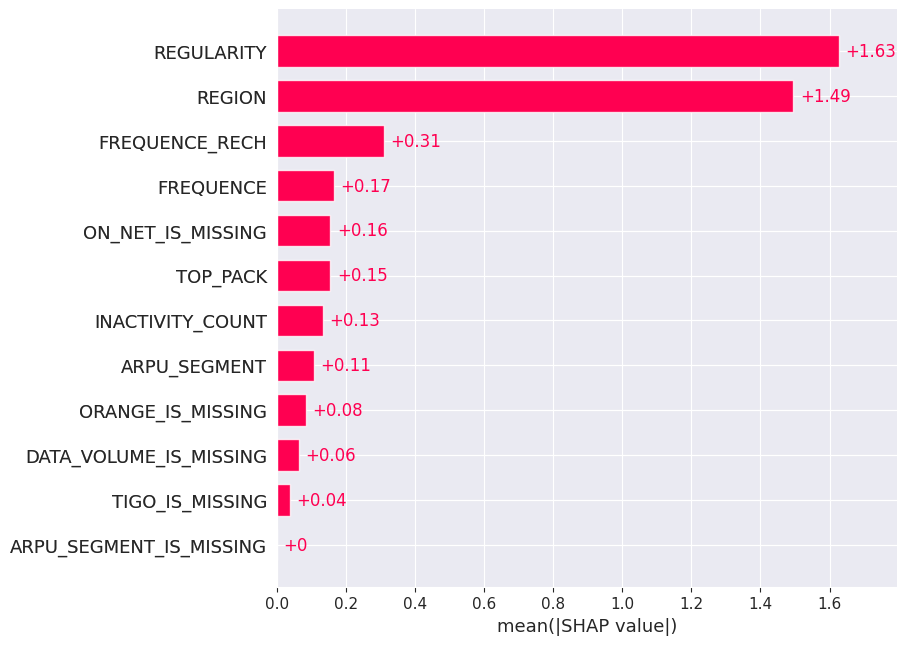

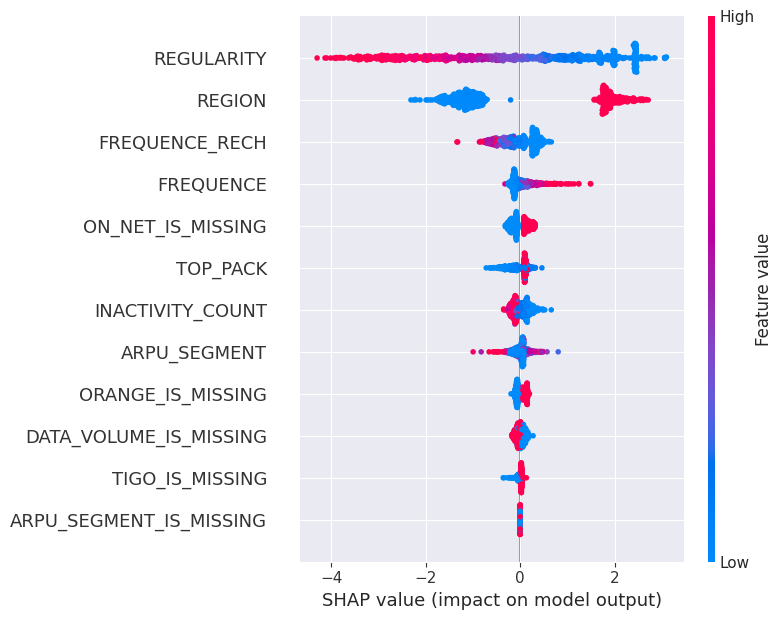

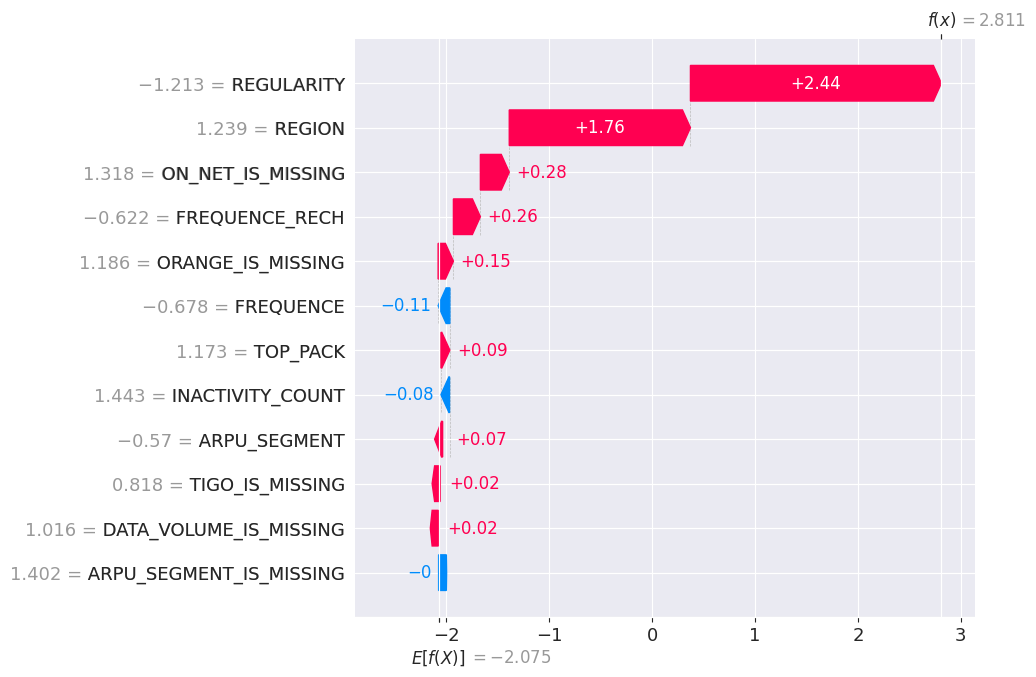

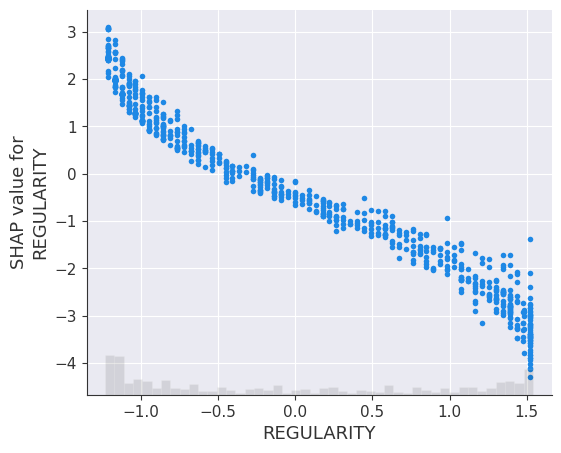

In [46]:
# =====================================================================
# 3. SHAP  (per-customer attributions that add up to the prediction)
# Question: for this customer, how much did each feature push the score up or down?
# Explains the fitted HGB step on the pipeline's transformed columns (the 25 engineered /
# scaled features, after ANOVA selection), in log-odds. Needs: pip install shap (preinstalled on Kaggle).
# =====================================================================
import shap

engineer = final_model.named_steps["engineer"]
prep = final_model.named_steps["preprocess"]
selector = final_model.named_steps["features"]
clf = final_model.named_steps["model"]

def to_model_space(X):
    Z = prep.transform(engineer.transform(X))
    names = np.asarray(prep.get_feature_names_out())
    if not isinstance(selector, str):                 # "passthrough" = no selection
        keep = selector.get_support()
        Z, names = Z[:, keep], names[keep]
    return Z, names

Z, feat_names = to_model_space(train_X.sample(n=min(5_000, len(train_X)), random_state=42))
order = np.random.default_rng(42).permutation(len(Z))
background, explain = Z[order[:100]], Z[order[100:900]]   # 800 customers keeps this to ~1-2 min

explainer = shap.Explainer(clf.decision_function, background, feature_names=feat_names)
sv = explainer(explain)                               # values are in log-odds of churn

# Global: average absolute contribution per feature
shap.plots.bar(sv, max_display=15)

# Global + direction: each dot is a customer, colour = feature value (red high, blue low)
shap.summary_plot(sv.values, explain, feature_names=feat_names, max_display=15)

# Local: why is the highest-risk customer in this sample flagged?
risk_idx = int(np.argmax(clf.decision_function(explain)))
shap.plots.waterfall(sv[risk_idx], max_display=12)

# Shape of f(x_i) for the top feature: contribution vs its value (scaled units)
top_feature = feat_names[np.abs(sv.values).mean(axis=0).argmax()]
shap.plots.scatter(sv[:, top_feature])

# Try to Submit

In [47]:
import os

# Use the class-weighted, grid-searched model from the Final Model section
if "final_model" not in globals():
    raise RuntimeError("final_model is not defined: run the Final Model section above first.")

test_pred = final_model.predict_proba(test_X[train_X.columns])[:, 1]
hgb_submission = pd.DataFrame({"user_id": test["user_id"], "CHURN": test_pred})

os.makedirs("/kaggle/working", exist_ok=True)
hgb_submission.to_csv("/kaggle/working/hgb_final_submission.csv", index=False)
print(hgb_submission.shape, "| missing values:", hgb_submission.isna().sum().sum())

(380127, 2) | missing values: 0
